# Cleaning & exploratory phase

In [ ]:
SELECT TOP 10 *
FROM dataco_staging

(10 rows affected)

Type     | Days for shipping (real) | Days for shipment (scheduled) | Benefit per order | Sales per customer | Delivery Status   | Late_delivery_risk | Category Id | Category Name  | Customer City | Customer Country | Customer Email | Customer Fname | Customer Id | Customer Lname | Customer Password | Customer Segment | Customer State | Customer Street          | Customer Zipcode | Department Id | Department Name | Latitude    | Longitude    | Market       | Order City | Order Country | Order Customer Id | order date (DateOrders) | Order Id | Order Item Cardprod Id | Order Item Discount | Order Item Discount Rate | Order Item Id | Order Item Product Price | Order Item Profit Ratio | Order Item Quantity | Sales  | Order Item Total | Order Profit Per Order | Order Region   | Order State     | Order Status    | Order Zipcode | Product Card Id | Product Category Id | Product Description | Product Image                                | Product Name | Product Price | Product Status | shippin

 creating a copy for the data table source for cleaning

In [ ]:
-- Loading copy of source data into a new table for cleaning and transformation

SELECT *
INTO dataco_clean
FROM dataco_staging

(Command completed successfully)

### Manipulating dataco_cleaning table columns regarding the python insights 
(python botebook is provided in the same github project folder)

In [ ]:
-- Product description 180519 null (100% null values), order zip code 155679 null (80%+ null values) ---> drop these columns from the dataco_clean table
-- Customer Email, Customer password, Product Status, and Product Image URL are all dummy data ---> drop these columns as well

ALTER TABLE dataco_clean
DROP COLUMN
    [Product Description], [Order Zipcode],
    [Customer Email], [Customer Password],
    [Product Status],[Product Image], [Benefit per order];

(Command completed successfully)

In [ ]:
-- [product category id] = ((category id)),
-- [Order Item Cardprod Id] = (([Product Card Id]))
-- [Order Item Product Price] = (([product price]))
-- all these are the same data with different columns. Decision: keep one of these

ALTER TABLE dataco_clean
DROP COLUMN [product category id],
            [Product Card Id],
            [Order Item Product Price],
            [order item total]

Commands completed successfully.

In [2]:
SELECT top 10 *
FROM dataco_clean

(10 rows affected)

Type    | Days for shipping (real) | Days for shipment (scheduled) | Sales per customer | Delivery Status  | Late_delivery_indicator | Category Id | Category Name        | Customer City | Customer Country | Customer Fname | Customer Id | Customer Lname | Customer Segment | Customer State | Customer Street           | Customer Zipcode | Department Id | Department Name | Latitude    | Longitude    | Market | Order City    | Order Country | Order Customer Id | order date (DateOrders) | Order Id | Order Item Cardprod Id | Order Item Discount | Order Item Discount Rate | Order Item Id | Order Item Product Price | Order Item Profit Ratio | Order Item Quantity | Sales  | Order Item Total | Order Profit Per Order | Order Region    | Order State      | Order Status    | Product Card Id | Product Category Id | Product Name                                  | Product Price | shipping date (DateOrders) | Shipping Mode  | Delay Time (Days) | custom severity score | State_Segment    | order_date_clea

In [ ]:
-- Order Item Id is a unique identifier for each item in an order ---> use this column as the primary key for the dataco_clean table

ALTER TABLE dataco_clean
ALTER COLUMN [Order Item Id] INT NOT NULL;
ALTER TABLE dataco_clean
ADD CONSTRAINT PK_OrderItemId PRIMARY KEY ([Order Item Id]);

Commands completed successfully.

In [ ]:
-- The column of "Late_delivery_risk" is a binary variable, where 1 indicates a late delivery and 0 indicates an on-time delivery. this name could be misleading, as it suggests that the column represents a risk score or probability of late delivery, rather than a binary outcome. A more appropriate name for this column could be "Late_delivery_indicator"
EXEC sp_rename 'dataco_clean.Late_delivery_risk', 'Late_delivery_indicator', 'COLUMN';

(Command completed successfully)

# Feature engineering

Adding a  custom severity score which is function of the number of days of delay for late deliveries. where the score is calculated as following:\
e^(number of days of delay). this make an exponential increase in the severity score as the number of days of delay increases, which can help to prioritize late deliveries based on their severity.

In [ ]:
-- Making a new column to calculate the delay time in days if exists, otherwise it will be null

ALTER TABLE dataco_clean
ADD [Delay Time (Days)] AS
    CASE
        WHEN [Late_delivery_indicator] = 1 THEN [Days for shipping (real)] - [Days for shipment (scheduled)]
        ELSE 0
    END;


(Command completed successfully)

In [ ]:
-- calculating g a custom severity score for late deliveries based on the delay time in days, where the score is calculated using an exponential function to give more weight to longer delays.

alter table dataco_clean
add [custom severity score] as
	CASE
	WHEN [Late_delivery_indicator] = 1  THEN ROUND(EXP(CAST(([Days for shipping (real)] - [Days for shipment (scheduled)]) AS FLOAT))-1,4)
	ELSE 0
	END

Severity level distribution 

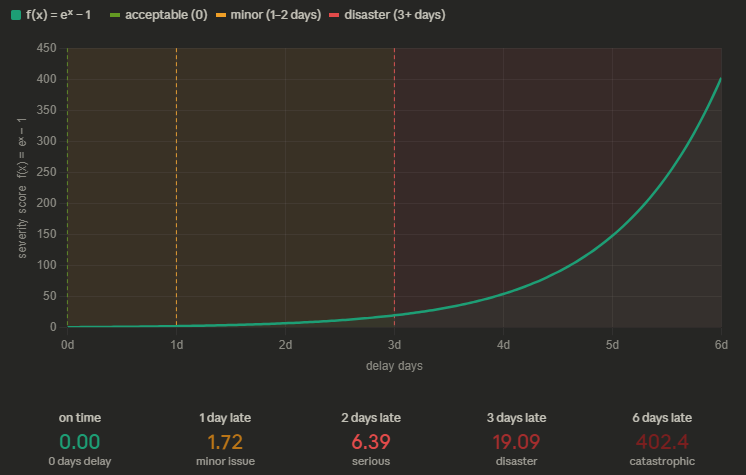

### Days of shipping Histogram plt



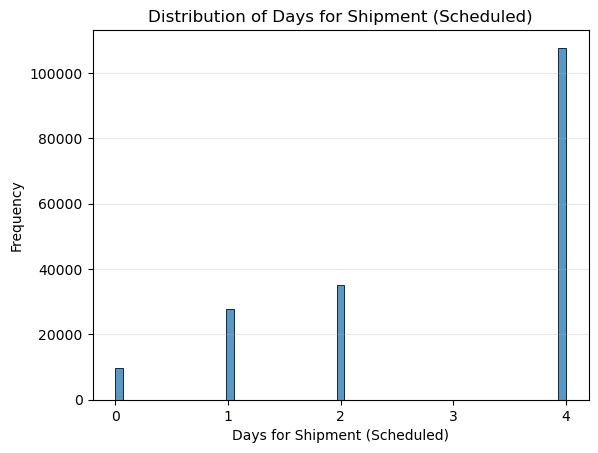     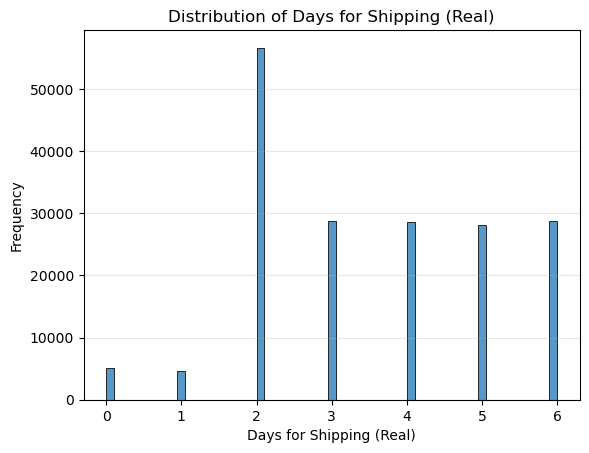

# Outliers analysis of python insights 

(the jupyter notebook of python is also provided in the same github file of the proect)

outlier analysis was done with  "IQR Method" with python in three columns:
1. Sales   &nbsp;         ||   &nbsp; &nbsp; &nbsp;   2.order profit per order  &nbsp;  &nbsp; &nbsp;    ||    &nbsp;&nbsp;&nbsp;  delay time (days)\
with the following results:


=== Sales ===\
Q1: 119.98 | Q3: 299.95 | IQR: 179.97\
Lower limit: -149.97 | Upper limit: 569.90\
Outliers count: 488 | Outliers %: 0.3%


=== Order Profit Per Order ===\
Q1: 7.00 | Q3: 64.80 | IQR: 57.80\
Lower limit: -79.62 | Upper limit: 151.45\
Outliers count: 18,942 | Outliers %: 10.5%


=== Delay Time (Days) ===\
Q1: 0.00 | Q3: 1.00 | IQR: 1.00\
Lower limit: -1.50 | Upper limit: 2.50\
Outliers count: 13,469 | Outliers %: 7.5%

In [ ]:
-- counting the number of late deliveries by severity score to see the distribution of late deliveries across different severity levels

SELECT
    COUNT(DISTINCT [Order Id]) AS total_orders,
    COUNT(DISTINCT CASE WHEN Late_delivery_indicator = 1 THEN [Order Id] END) AS late_orders,
    FORMAT(1.0 * COUNT(DISTINCT CASE WHEN Late_delivery_indicator = 1 THEN [Order Id] END) / COUNT(DISTINCT [Order Id]), 'p') AS delay_pct
FROM dataco_clean


-- 50%+ of the orders are late deliveries, which indicates a significant issue with the delivery process.

(1 row affected)

total_orders | late_orders | delay_pct
-------------+-------------+----------
65752        | 36048       | 54.82%   
(1 row)

# Financial analysis

## Adding non revenue flag & creating filtered financial analysis view

focusing on the highest outlier frequency "Order profit per order" with a significant number of outliers (10%+)\
diving deep with python analysis, breaking down the state of each outlier type obtained this:
\
\
Loss outliers (below -$79.70): 13,727\
Gain outliers (above $151.50): 5,215

Average los outlier: $-239.24\
Average gain outlier: $195.12\
\
that means

total_loss_damage  = 13727 * 239.24  =  $3,284,218\
total_gain_benefit =  5215 * 195.12  =  $1,017,901\
net_outlier_impact = $1,017,901 - $3,284,218 = -$2,266,317


In [1]:
SELECT DISTINCT
    [Order Status]
FROM dataco_clean

-- noted here 'Order status' has values of 'CANCELED', 'SUSPECTED_FRAUD', and 'PAYMENT_REVIEW' that isn't relevant for financial analysis and lead to zero profit
-- Approach: make a financial view excluding these three status for more accurate analysis

(9 rows affected)

Order Status   
---------------
CANCELED       
CLOSED         
COMPLETE       
ON_HOLD        
PAYMENT_REVIEW 
PENDING        
PENDING_PAYMENT
PROCESSING     
SUSPECTED_FRAUD
(9 rows)

Total execution time: 00:00:01.021

Create non_revenue_flag to indicate if this order could be neglected from financial analysis   

In [ ]:
ALTER TABLE dataco_clean
ADD non_revenue_flag TINYINT

Commands completed successfully.

In [ ]:
WITH flag_logic AS(
	SELECT
		[Order Item Id],
		(CASE WHEN [Order Status] IN ('CANCELED', 'SUSPECTED_FRAUD') THEN 1 ELSE 0 END) set_flag
	FROM dataco_clean
)
UPDATE d
SET d.non_revenue_flag = f.set_flag
FROM dataco_clean d
JOIN flag_logic f ON f.[Order Item Id] = d.[Order Item Id]

(180519 rows affected)

In [1]:
CREATE OR ALTER VIEW vw_financial_orders AS
SELECT *
FROM dataco_clean
WHERE non_revenue_flag = 0

Commands completed successfully.

=== Adjusted Profit Outlier Analysis ===\
Q1: 7.03 | Q3: 64.80 | IQR: 57.77\
Lower Limit: -79.62 | Upper Limit: 151.45\
Total outliers: 17,922\
Lower Outlier Count: 12,982 | Upper Outlier Count: 4,940\
Outlier %: 10.5 %

=== In financial terms that means ===\
Total_loss_damage = -3,103,723.36\
Total_benefit_gain = 963,745.03\
Net outlier_impact = -2,139,978.33

## Root caus analysis for financial outliers

This rises three questoin
1. Q1 — Do loss outlier orders have higher discounts?
2. Q2 —Which product categories generate the most loss outliers?
3. Q3 — Which markets have the worst loss outlier concentration?

### Discount analysis

In [3]:
-- 1. Q1 — Do loss outlier orders have higher discounts?

SELECT
    CASE
        WHEN [Order Profit Per Order] < -79.62 THEN 'Loss Outliers'
        WHEN [Order Profit Per Order] > 151.45 THEN 'Gain Outliers'
        ELSE 'Non-Outliers'
    END AS Outlier_Type,
    AVG([Order Item Discount Rate]) AS Avg_Discount_Rate,
    AVG([Order Profit Per Order]) AS Avg_Profit_Per_Order
FROM vw_financial_orders
GROUP BY
    CASE
        WHEN [Order Profit Per Order] < -79.62 THEN 'Loss Outliers'
        WHEN [Order Profit Per Order] > 151.45 THEN 'Gain Outliers'
        ELSE 'Non-Outliers'
    END
    ORDER BY Avg_Profit_Per_Order DESC;

-- This indicates that loss outliers aren't probably correlated with higher discount rates.

(3 rows affected)

Outlier_Type  | Avg_Discount_Rate   | Avg_Profit_Per_Order
--------------+---------------------+---------------------
Gain Outliers | 0.08429959514170046 | 195.09008704453444  
Non-Outliers  | 0.10251376266753338 | 38.59411683556707   
Loss Outliers | 0.09798028038823024 | -239.07898320751832 
(3 rows)

Discount - loss distribution

In [4]:
SELECT
    ROUND(CAST([Order Item Discount Rate] AS FLOAT) * 100, 0) AS discount_pct_bucket,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN [Order Profit Per Order] <= 0 THEN 1 ELSE 0 END) AS loss_orders,
    ROUND(1.0 * SUM(CASE WHEN [Order Profit Per Order] <= 0 THEN 1 ELSE 0 END)
          / COUNT(*) * 100, 2) AS loss_rate_pct,
    ROUND(AVG(CAST([Order Profit Per Order] AS FLOAT)), 2) AS avg_profit,
    ROUND(AVG(CAST([Order Item Discount Rate] AS FLOAT)) * 100, 2) AS avg_discount
FROM vw_financial_orders
GROUP BY ROUND(CAST([Order Item Discount Rate] AS FLOAT) * 100, 0)
ORDER BY discount_pct_bucket;

(18 rows affected)

discount_pct_bucket | total_orders | loss_orders | loss_rate_pct   | avg_profit | avg_discount
--------------------+--------------+-------------+-----------------+------------+-------------
0                   | 9524         | 1833        | 19.250000000000 | 26.36      | 0           
1                   | 9494         | 1807        | 19.030000000000 | 24.13      | 1           
2                   | 9506         | 1798        | 18.910000000000 | 23.87      | 2           
3                   | 9461         | 1886        | 19.930000000000 | 22.16      | 3           
4                   | 9479         | 1868        | 19.710000000000 | 22.93      | 4           
5                   | 9504         | 1830        | 19.260000000000 | 24.27      | 5           
6                   | 9516         | 1791        | 18.820000000000 | 23.65      | 6           
7                   | 9496         | 1852        | 19.500000000000 | 23.27      | 7           
9                   | 9492         | 1777        |

### Category analysis

In [ ]:
SELECT
    [Category Name],
    COUNT(*) AS Total_loss_outliers,
    CAST(100.0 * SUM(CASE WHEN CAST([Order Profit Per Order] AS FLOAT) < -79.62 THEN 1 ELSE 0 END) / sum(count(*)) over()AS decimal(10,2)) AS loss_outlier_pct,
    AVG(CAST([Order Profit Per Order] AS decimal(10,2))) AS avg_loss_per_order,
    SUM(CAST([Order Profit Per Order] AS FLOAT)) AS total_money_lost
FROM vw_financial_orders
WHERE [Order Profit Per Order] < -79.62 -- TARGETING LOSS OUTLIERS
GROUP BY [Category Name]
ORDER BY total_money_lost ASC;

-- Q2 seems to be more revealing more than Q1, there are some categories responsible for more losses than others, and this could be a good starting point for further investigation into the specific products or factors contributing to these losses.
-- fishing category alone is responsible for total losses of 675K+ and category of 'camping & hiking' is responsible for ~400K losses.

(47 rows affected)

Category Name        | Total_loss_outliers | loss_outlier_pct | avg_loss_per_order | total_money_lost   
---------------------+---------------------+------------------+--------------------+--------------------
Fishing              | 1901                | 14.64            | -336.007354        | -638749.9799999999 
Camping & Hiking     | 1311                | 10.10            | -285.836048        | -374731.0600000001 
Cleats               | 1631                | 12.56            | -213.751949        | -348629.43         
Cardio Equipment     | 1109                | 8.54             | -310.790027        | -344666.14         
Water Sports         | 1336                | 10.29            | -207.441182        | -277141.42000000004
Women's Apparel      | 1217                | 9.37             | -195.211635        | -237572.56         
Men's Footwear       | 1512                | 11.65            | -149.185906        | -225569.09000000005
Indoor/Outdoor Games | 1138                | 8.77      

In [16]:
-- counting the number of the loss outliers, profit outlier, and normal orders by each category
SELECT
    [Category Name],
    CAST((SUM(CASE WHEN [Order Profit Per Order] < -79.62 THEN 1 ELSE 0 END)) AS INT) AS Loss_Outliers,
    CAST((SUM(CASE WHEN [Order Profit Per Order] > 151.45 THEN 1 ELSE 0 END)) AS INT) AS Gain_Outliers,
    CAST((SUM(CASE WHEN [Order Profit Per Order] BETWEEN -79.62 AND 151.45 THEN 1 ELSE 0 END)) AS INT) AS Non_Outliers
FROM dataco_clean
GROUP BY [Category Name]
ORDER BY Loss_Outliers DESC;

-- This query shows that, categories of "Fishing" and "Cardio Equipment" have significant number of orders in both loss and gain outliers,
-- which indicates that these categories have a higher variability in order profit.

(50 rows affected)

Category Name        | Loss_Outliers | Gain_Outliers | Non_Outliers
---------------------+---------------+---------------+-------------
Fishing              | 2022          | 3036          | 12267       
Cleats               | 1727          | 0             | 22824       
Men's Footwear       | 1601          | 0             | 20645       
Water Sports         | 1403          | 4             | 14133       
Camping & Hiking     | 1383          | 0             | 12346       
Women's Apparel      | 1285          | 0             | 19750       
Indoor/Outdoor Games | 1201          | 0             | 18097       
Cardio Equipment     | 1168          | 1206          | 10113       
Shop By Sport        | 628           | 0             | 10356       
Electronics          | 175           | 0             | 2981        
Children's Clothing  | 73            | 79            | 500         
Cameras              | 70            | 138           | 384         
Computers            | 69            | 311      

In [5]:
-- summing the total profit loss and total profit gain by category to see the net profit or loss for each category
SELECT
    [Category Name],
    CAST(SUM(CASE WHEN [Order Profit Per Order] < -79.62 THEN [Order Profit Per Order] ELSE 0 END) AS decimal(10,2)) AS Total_Loss_Outliers,
    CAST(SUM(CASE WHEN [Order Profit Per Order] > 151.45 THEN [Order Profit Per Order] ELSE 0 END) AS decimal(10,2)) AS Total_Gain_Outliers,
    CAST(SUM(CASE WHEN [Order Profit Per Order] BETWEEN -79.62 AND 151.45 THEN [Order Profit Per Order] ELSE 0 END) AS decimal(10,2)) AS Neutral_Profit,
    FORMAT(SUM([Order Profit Per Order]),'n1') AS Total_Profit
FROM vw_financial_orders
GROUP BY [Category Name]
ORDER BY SUM([Order Profit Per Order]) DESC;
-- Our top profitable category has the highest value of total Outlier loss!
-- Our top 9 profitable categories have more loss outliers than gain outliers. This is a hug variation in order profit,
--which indicates that there are some factors contributing to significant losses in these categories, and further investigation is needed to identify and address these factors to improve profitability.

(50 rows affected)

Category Name        | Total_Loss_Outliers | Total_Gain_Outliers | Neutral_Profit | Total_Profit
---------------------+---------------------+---------------------+----------------+-------------
Fishing              | -638749.98          | 499635.86           | 864280.22      | 725,166.1   
Cleats               | -348629.43          | 0.00                | 816704.16      | 468,074.7   
Camping & Hiking     | -374731.06          | 0.00                | 778570.96      | 403,839.9   
Cardio Equipment     | -344666.14          | 209940.37           | 492579.87      | 357,854.1   
Women's Apparel      | -237572.56          | 0.00                | 566871.86      | 329,299.3   
Water Sports         | -277141.42          | 657.05              | 582490.76      | 306,006.4   
Indoor/Outdoor Games | -217967.44          | 0.00                | 516333.65      | 298,366.2   
Men's Footwear       | -225569.09          | 0.00                | 521187.64      | 295,618.6   
Shop By Sport        | -97085.

In [ ]:
WITH profit_status AS (
    SELECT
        [Category Name],
        SUM([Order Profit Per Order]) AS Total_profit,
        SUM(CASE WHEN [Order Profit Per Order] < 0 THEN [Order Profit Per Order] ELSE 0 END) AS Total_Loss,
        SUM(CASE WHEN [Order Profit Per Order] < -79.62 THEN [Order Profit Per Order] ELSE 0 END) AS outlier_losses
    FROM vw_financial_orders
    GROUP BY [Category Name]
)

SELECT
    p.[Category Name],
    FORMAT(SUM(v.Sales), 'n') AS Total_Sales,
    FORMAT(p.Total_profit, 'n') AS Total_profit,
    FORMAT((Total_profit/SUM(v.Sales)),'p') profitability,
    FORMAT(Total_Loss,'n') Total_loss,
    FORMAT(-1*Total_Loss/Total_profit,'p') loss_to_profit_ratio,                          -- How much we lose for each Dollar we make
    FORMAT(p.Total_profit - p.outlier_losses, 'n') AS profit_without_outlier_losses,      -- What would our profit be if we could eliminate outlier loss-making orders?
    FORMAT(p.Total_profit - p.Total_Loss, 'n') AS profit_without_losses                   -- What would our profit be if we could eliminate ALL loss-making orders?
FROM vw_financial_orders v
JOIN profit_status p ON p.[Category Name] = v.[Category Name]
GROUP BY
    p.[Category Name],
    p.Total_profit,
    p.Total_Loss,
    p.outlier_losses
ORDER BY p.Total_profit DESC;

-- Our top performers are running at loss to profit ratio of about 100% or more. that means for every dollar we make we los one or more
-- Strength Training category is running with ~5,000% loss to profit ratio with very low profitability and very high sales volume compering to other categories with the same profit value

(50 rows affected)

Category Name        | Total_Sales  | Total_profit | profitability | Total_loss  | loss_to_profit_ratio | profit_without_outlier_losses | profit_without_losses
---------------------+--------------+--------------+---------------+-------------+----------------------+-------------------------------+----------------------
Fishing              | 6,567,271.62 | 725,166.10   | 11.04%        | -684,783.80 | 94.43%               | 1,363,916.08                  | 1,409,949.90         
Cleats               | 4,196,421.92 | 468,074.73   | 11.15%        | -428,493.60 | 91.54%               | 816,704.16                    | 896,568.33           
Camping & Hiking     | 3,904,539.68 | 403,839.90   | 10.34%        | -420,376.74 | 104.09%              | 778,570.96                    | 824,216.64           
Cardio Equipment     | 3,493,263.18 | 357,854.10   | 10.24%        | -383,299.44 | 107.11%              | 702,520.24                    | 741,153.54           
Women's Apparel      | 2,976,900.00 | 32

Q3 — Which markets have the worst loss outlier concentration?

In [8]:
SELECT
    [order region],
    COUNT(*) AS Total_loss_outliers,
    CAST(100.0 * SUM(CASE WHEN CAST([Order Profit Per Order] AS FLOAT) < -79.62 THEN 1 ELSE 0 END) / sum(count(*)) over()AS decimal(10,2)) AS loss_outlier_pct,
    AVG(CAST([Order Profit Per Order] AS decimal(10,2))) AS avg_loss_per_order,
    SUM(CAST([Order Profit Per Order] AS FLOAT)) AS total_money_lost
FROM vw_financial_orders
WHERE [Order Profit Per Order] < -79.62 -- TARGETING LOSS OUTLIERS
GROUP BY [order region]
ORDER BY total_money_lost ASC;

-- This indicates a disaster, the western Europe region and Central America are responsible for 500K+ losses with 15%+ of their orders being loss outliers,
-- these regions should be among our top performance. these are rich regions with high living standards and high income per capita,
-- this indicates that there are some specific issues in these regions that need to be investigated and addressed to reduce losses and improve profitability.

(23 rows affected)

order region    | Total_loss_outliers | loss_outlier_pct | avg_loss_per_order | total_money_lost   
----------------+---------------------+------------------+--------------------+--------------------
Western Europe  | 1985                | 15.29            | -253.424841        | -503048.31         
Central America | 2074                | 15.98            | -231.279358        | -479673.3899999999 
South America   | 1031                | 7.94             | -230.815819        | -237971.11000000002
Northern Europe | 739                 | 5.69             | -250.800798        | -185341.78999999998
Oceania         | 732                 | 5.64             | -245.923428        | -180015.95         
Southern Europe | 650                 | 5.01             | -252.211061        | -163937.18999999997
Southeast Asia  | 684                 | 5.27             | -237.579502        | -162504.38         
Caribbean       | 613                 | 4.72             | -233.865106        | -143359.31         


In [10]:
DECLARE @loss_fence FLOAT = -79.62;

SELECT
    [order region],
    COUNT(*) AS fishing_loss_outliers,
    ROUND(AVG(CAST([Order Profit Per Order] AS FLOAT)), 2) AS avg_loss,
    ROUND(AVG(CAST([Sales] AS FLOAT)), 2) AS avg_sales
FROM vw_financial_orders
WHERE [Category Name] = 'Fishing'
AND CAST([Order Profit Per Order] AS FLOAT) < @loss_fence
GROUP BY [order region]
ORDER BY fishing_loss_outliers DESC;

(23 rows affected)

order region    | fishing_loss_outliers | avg_loss | avg_sales
----------------+-----------------------+----------+----------
Central America | 299                   | -329.75  | 399.98   
Western Europe  | 284                   | -321.9   | 399.98   
South America   | 166                   | -329.43  | 399.98   
Southern Europe | 109                   | -313.95  | 399.98   
Caribbean       | 97                    | -368.51  | 399.98   
Northern Europe | 95                    | -349.5   | 399.98   
Southeast Asia  | 93                    | -325.54  | 399.98   
Oceania         | 91                    | -365.79  | 399.98   
West of USA     | 87                    | -333.56  | 399.98   
Eastern Asia    | 86                    | -366.98  | 399.98   
South Asia      | 78                    | -328.17  | 399.98   
East of USA     | 67                    | -316.22  | 399.98   
West Asia       | 62                    | -341.52  | 399.98   
US Center       | 58                    | -310.55  | 39

In [4]:
DECLARE @Outlier_Threshold DECIMAL(10,2) = -79.62;
DECLARE @Total_orders FLOAT = (SELECT COUNT (*) FROM vw_financial_orders);

SELECT
    COUNT(*) Losing_Orders,
    FORMAT((COUNT(*)/ @Total_orders),'p') Losing_Orders_pct,
    (SUM(CASE WHEN [Order Profit Per Order] <@Outlier_Threshold THEN 1 ELSE 0 END)) Outlier_Losing_orders,
    FORMAT((SUM(CASE WHEN [Order Profit Per Order] < @Outlier_Threshold THEN 1.0 ELSE 0 END)) / @Total_orders,'p') Outlier_Losing_order_pct,
    FORMAT((SUM(CASE WHEN [Order Profit Per Order] < @Outlier_Threshold THEN 1.0 ELSE 0 END))/COUNT(*),'p') Outlier_pct_of_total_losing
FROM vw_financial_orders
WHERE [Order Profit Per Order] <=0
-- about 20% of orders are losing orders, about 40% of them are outlier orders.
-- Even this critical outliers solved still significant amount of loesses (~60%) pulling the potential overall profit for our most selling products down

(1 row affected)

Losing_Orders | Losing_Orders_pct | Outlier_Losing_orders | Outlier_Losing_order_pct | Outlier_pct_of_total_losing
--------------+-------------------+-----------------------+--------------------------+----------------------------
33411         | 19.34%            | 13126                 | 7.60%                    | 39.29%                     
(1 row)

Total execution time: 00:00:01.012

In [5]:
CREATE OR ALTER PROCEDURE GetLossMetrics
    @AnalyzeBy NVARCHAR(128) = 'Category Name',  -- Default Perspective
    @Threshold DECIMAL(10,2) = -79.62           -- Default IQR Outlier
AS
BEGIN
    SET NOCOUNT ON;
    DECLARE @DynamicSQL NVARCHAR(MAX);
    DECLARE @TotalCount FLOAT = (SELECT COUNT(*) FROM dataco_clean);
    -- Building the SQL string
    SET @DynamicSQL = N'
    SELECT
        ' + QUOTENAME(@AnalyzeBy) + ' AS [Analysis_Perspective],
        COUNT(*) AS [Losing_Orders],
        FORMAT(1.00 * COUNT(*) / ' + CAST(@TotalCount AS NVARCHAR(20)) + ', ''p'')
            AS [Losing_Orders_pct],
        SUM(CASE WHEN [Order Profit Per Order] < ' + CAST(@Threshold AS NVARCHAR(20)) + ' THEN 1 ELSE 0 END)
            AS [Outlier_Losing_orders],
        FORMAT(1.00 * SUM(CASE WHEN [Order Profit Per Order] < ' + CAST(@Threshold AS NVARCHAR(20)) + ' THEN 1 ELSE 0 END) / ' + CAST(@TotalCount AS NVARCHAR(20)) + ', ''p'')
            AS [Outlier_Losing_order_pct],
        FORMAT(1.00 * SUM(CASE WHEN [Order Profit Per Order] < ' + CAST(@Threshold AS NVARCHAR(20)) + ' THEN 1 ELSE 0 END) /
        NULLIF(COUNT(*), 0), ''p'')
            AS [Outlier_pct_of_total_losing]
    FROM vw_financial_orders
    WHERE [Order Profit Per Order] <= 0
    GROUP BY ' + QUOTENAME(@AnalyzeBy) + '
    ORDER BY [Losing_Orders] DESC;';
    EXEC sp_executesql @DynamicSQL;
END

Commands completed successfully.

In [6]:
GetLossMetrics

-- GetLossMetrics has 2 metrics, the column on which the analysis is done by (@AnalyzeBy), and the lose in profit in which is considered to be outlier (@Threshold)
-- The default value for @AnalyzeBy = 'Category Name' and the default value of @Threshold = -79.62 (This number is obtained for statistical analysis of IQR)
-- For full control try other values like 'GetLossMetrics @AnalyzeBy= 'order region', @Threshold = 50.00

Commands completed successfully.

Analysis_Perspective | Losing_Orders | Losing_Orders_pct | Outlier_Losing_orders | Outlier_Losing_order_pct | Outlier_pct_of_total_losing
---------------------+---------------+-------------------+-----------------------+--------------------------+----------------------------
Cleats               | 4487          | 2.49%             | 1631                  | 0.90%                    | 36.35%                     
Men's Footwear       | 4080          | 2.26%             | 1512                  | 0.84%                    | 37.06%                     
Women's Apparel      | 3825          | 2.12%             | 1217                  | 0.67%                    | 31.82%                     
Indoor/Outdoor Games | 3555          | 1.97%             | 1138                  | 0.63%                    | 32.01%                     
Fishing              | 3113          | 1.72%             | 1901                  | 1.05%                    | 61.07%                     
Water Sports         | 2859       

**sticking outlier status for each order**

In [10]:
ALTER TABLE dataco_clean
ADD profit_segment NVARCHAR(20)

Commands completed successfully.

In [14]:
DECLARE @loss_outlier FLOAT = -79.62;
DECLARE @gain_outlier FLOAT = 151.45;

WITH outlier_gate AS(
    SELECT
        [Order Item Id],
        (CASE
            WHEN [Order Profit Per Order] BETWEEN @loss_outlier AND 0 THEN 'loss'
            WHEN [Order Profit Per Order] < @loss_outlier THEN 'outlier loss'
            WHEN [Order Profit Per Order] > @gain_outlier THEN 'outlier gain'
            ELSE 'Normal'
        END) profit_segment_gate
    FROM dataco_clean
)
UPDATE d
SET d.profit_segment = o.profit_segment_gate
FROM dataco_clean d
JOIN outlier_gate o ON d.[Order Item Id] = o.[Order Item Id];

(180519 rows affected)

**Cross- category sales volume analysis. This illustrate if two products sales are correlated, as one demand's increase the other product demand increase as well**

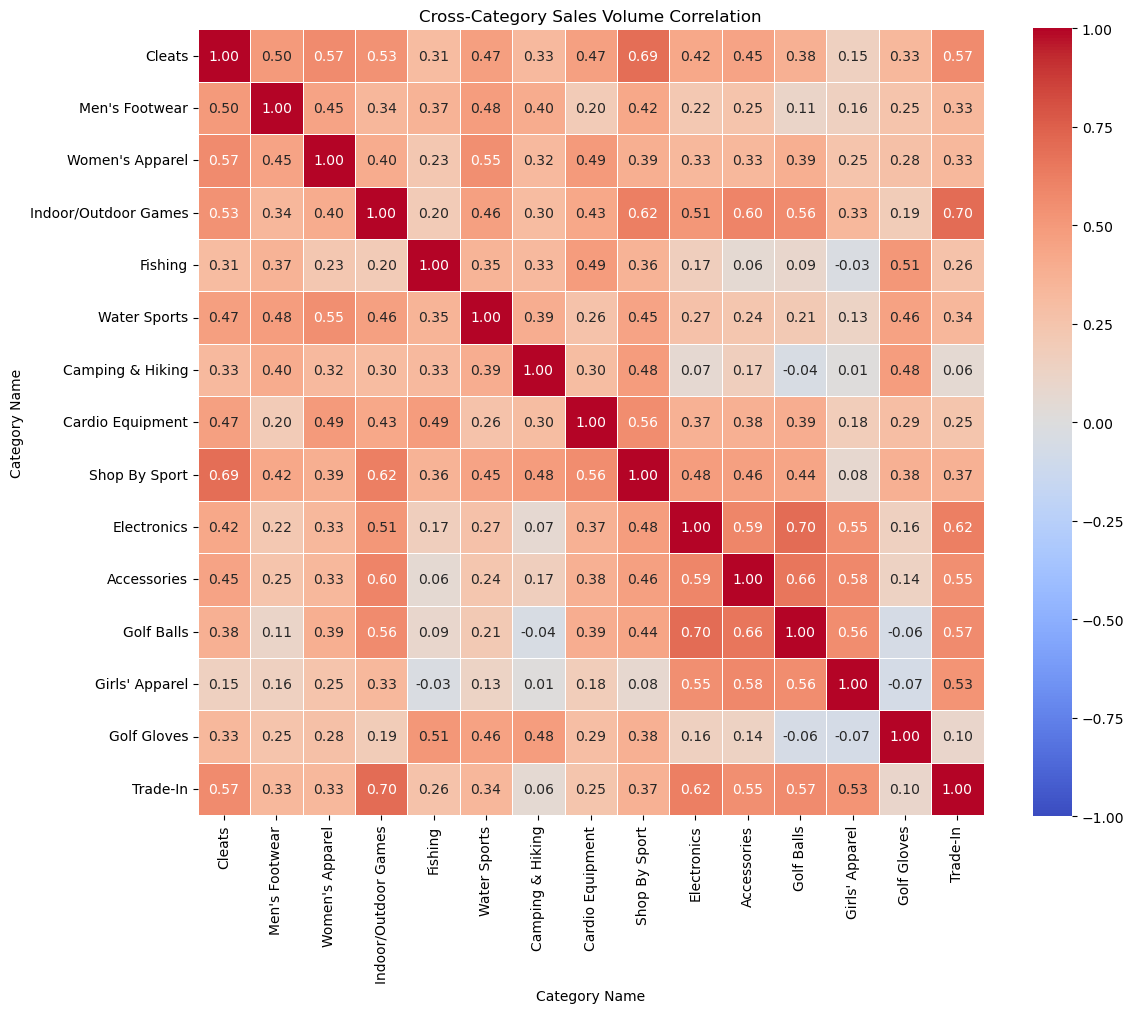

In [5]:
-- top categories correlation table (function code and pushing to SQL codes are provided in the python notebook provided in the same project folder)

SELECT * FROM category_correlations_strong

(22 rows affected)

Category_A           | Category_B           | correlation       
---------------------+----------------------+-------------------
Indoor/Outdoor Games | Trade-In             | 0.7027913753456992
Electronics          | Golf Balls           | 0.7023838240165801
Cleats               | Shop By Sport        | 0.6911983211341232
Accessories          | Golf Balls           | 0.6614690137620909
Indoor/Outdoor Games | Shop By Sport        | 0.6236425676058526
Electronics          | Trade-In             | 0.6207949654277355
Accessories          | Indoor/Outdoor Games | 0.5999452922689655
Accessories          | Electronics          | 0.586705206566313 
Accessories          | Girls' Apparel       | 0.5790395316557834
Golf Balls           | Trade-In             | 0.5679617016457333
Cleats               | Trade-In             | 0.5655662370443247
Cleats               | Women's Apparel      | 0.5655372940591309
Golf Balls           | Indoor/Outdoor Games | 0.5629332171926449
Cardio Equipment     | Sh

# Fixing state names (States with undefined characters in the source csv file)

In [ ]:
-- Calculating the number of distinct states to get a glance of the over all problems

SELECT
    COUNT(DISTINCT[Order State]) [Total states]
FROM dataco_clean

-- 1086 states for a normal fixing! cleaning this number is definitely an excess work and time
-- The cleaning approach: applying pareto principle. only ~20% of states are responsible for 80% of the total profit,
-- these 20% (important few) ---> manual inspection and cleaning
-- the rest 80% (trivial many) ---> can be handled by group segmentation without getting into one by one details

(1 row affected)

Total states
------------
1086        
(1 row)

In [7]:
WITH StateProfit AS (
    SELECT
        [Order State],
        SUM([Order Profit Per Order]) AS Total_State_Profit
    FROM vw_financial_orders
    GROUP BY [Order State]
    HAVING SUM([Order Profit Per Order]) > 0  -- only profitable states
),
CumulativeAnalysis AS (
    SELECT
        [Order State],
        Total_State_Profit,
        SUM(Total_State_Profit) OVER (ORDER BY Total_State_Profit DESC) AS Running_Total,
        SUM(Total_State_Profit) OVER () AS Grand_Total
    FROM StateProfit
)
SELECT
    [Order State],
    ROUND(Total_State_Profit, 2) AS Total_State_Profit,
    FORMAT(Running_Total / Grand_Total, 'p') AS Cumulative_Percentage,
    ROW_NUMBER() OVER (ORDER BY Total_State_Profit DESC) AS State_Rank
FROM CumulativeAnalysis
WHERE Running_Total / Grand_Total <= 0.8
ORDER BY Total_State_Profit DESC;

-- Note: for running cumulative the states with negative profit were excluded
-- with 219 store still much effort for manual inspection and fixing, specially with very low level of details and insignificance of each individual state.

(218 rows affected)

Order State                          | Total_State_Profit | Cumulative_Percentage | State_Rank
-------------------------------------+--------------------+-----------------------+-----------
Inglaterra                           | 159067.37          | 4.18%                 | 1         
Isla de Francia                      | 119363.95          | 7.32%                 | 2         
California                           | 97977.28           | 9.90%                 | 3         
Nueva York                           | 56737.95           | 11.39%                | 4         
Distrito Federal                     | 56003.31           | 12.87%                | 5         
San Salvador                         | 55841.53           | 14.34%                | 6         
Texas                                | 52784.91           | 15.72%                | 7         
Renania del Norte-Westfalia          | 49950.43           | 17.04%                | 8         
Nueva Gales del Sur                  | 49082.07   

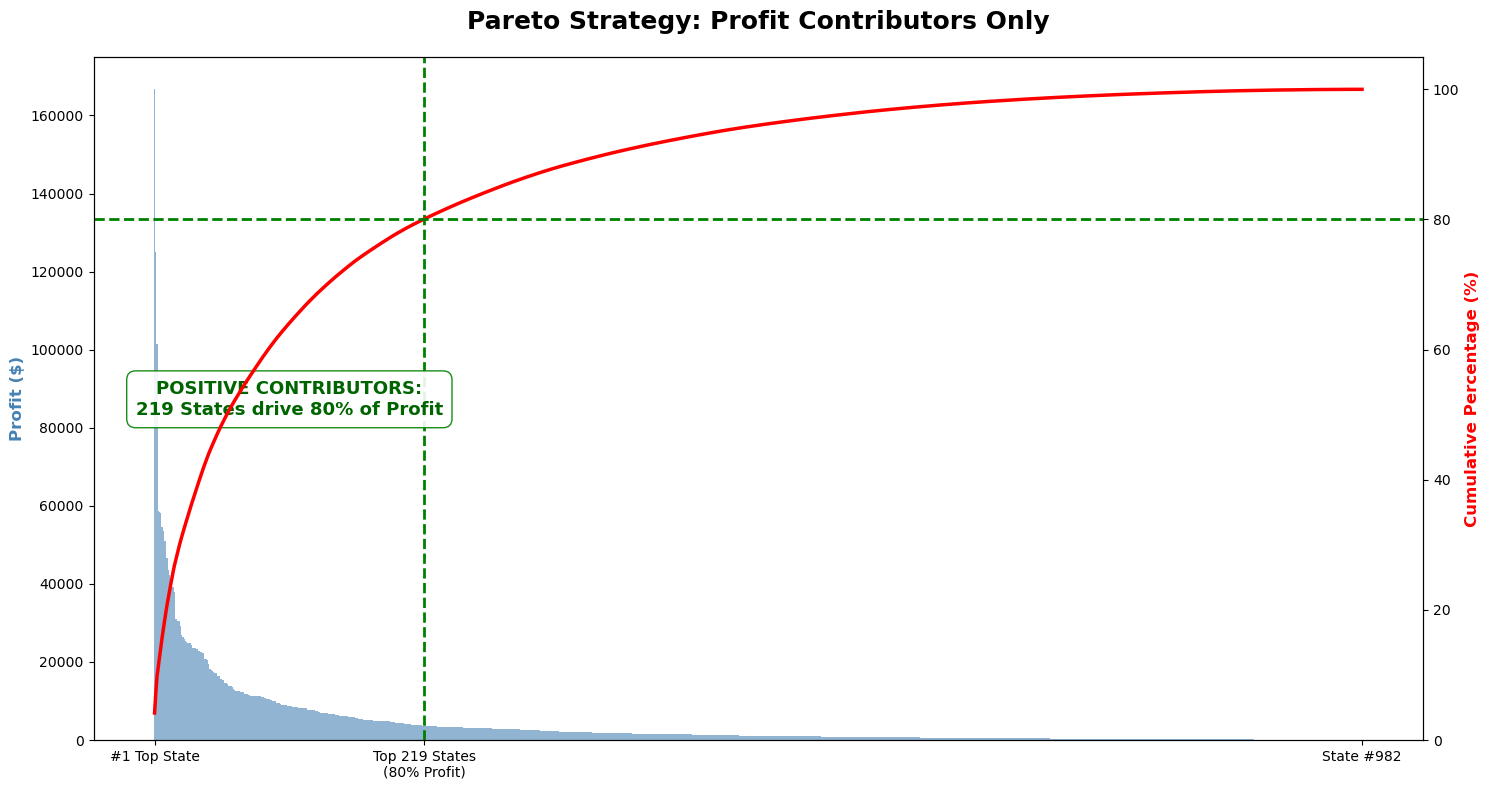

## Order State Column — Decision To Exclude

The dataset contains 1,086 distinct state values spanning multiple 
languages (Spanish, French, English) across 5 global markets. 
Pareto analysis identified 219 states accounting for 80% of profit — 
too many for manual cleaning given the availability of cleaner 
higher-level geographic columns (Market, Order Region, Order Country).

Decision: Order State excluded from geographic analysis. 
Market and Order Region used as primary geographic dimensions.

In [3]:
WITH Profit_Per_state AS (
    SELECT
        [Order state],
        SUM([Order Profit Per Order]) AS Total_State_Profit
    FROM dataco_clean
    GROUP BY [Order State]
),
CumulativeAnalysis AS (
    SELECT
        [Order State],
        Total_State_Profit,
        -- CRITICAL FIX: Added DESC so the running total starts with the biggest profits
        SUM(CASE WHEN Total_State_Profit > 0 THEN Total_State_Profit ELSE 0 END)
            OVER(ORDER BY Total_State_Profit DESC) AS Running_Total,
        SUM(CASE WHEN Total_State_Profit > 0 THEN Total_State_Profit ELSE 0 END)
            OVER() AS Grand_Total
    FROM Profit_Per_state
),
Segmentation_analysis AS (
    SELECT
        [Order State],
        Total_State_Profit,
        CASE
            WHEN Total_State_Profit < 0 THEN 'Losing_State'
            WHEN Total_State_Profit = 0 THEN 'Uncategorized'
            WHEN CAST(Running_Total AS FLOAT) / Grand_Total <= 0.5 THEN 'Star_State'
            WHEN CAST(Running_Total AS FLOAT) / Grand_Total <= 0.8 THEN 'Moderate_state'
            ELSE 'Under_performing'
        END AS Segment
    FROM CumulativeAnalysis
)
SELECT TOP 50
    [Order State],
    Total_State_Profit,
    Segment
FROM Segmentation_analysis
ORDER BY
    CASE Segment
        WHEN 'Star_State' THEN 1
        WHEN 'Moderate_state' THEN 2
        WHEN 'Under_performing' THEN 3
        WHEN 'Uncategorized' THEN 4
        WHEN 'Losing_State' THEN 5
    END, Total_State_Profit DESC;
-- With only 4 possible categories this now more reliable state analysis and could be pushed into the table to be used in further visual and technical analysis

(50 rows affected)

Order State                          | Total_State_Profit | Segment   
-------------------------------------+--------------------+-----------
Inglaterra                           | 166693.40999999992 | Star_State
Isla de Francia                      | 124945.76999999997 | Star_State
California                           | 101563.16000000002 | Star_State
Nueva York                           | 58774.54000000001  | Star_State
Distrito Federal                     | 58474.51           | Star_State
San Salvador                         | 58095.03999999999  | Star_State
Texas                                | 54664.94999999998  | Star_State
Renania del Norte-Westfalia          | 53616.85           | Star_State
Santo Domingo                        | 51111.67           | Star_State
Nueva Gales del Sur                  | 51093.74999999999  | Star_State
Sï?½ï?½ï?                            | 46751.83999999999  | Star_State
Capital Nacional                     | 43472.17          

In [ ]:
-- adding the segmenting column

ALTER TABLE dataco_clean
ADD State_Segment NVARCHAR(20)

Commands completed successfully.

In [ ]:
-- Assuming you already added the column: ALTER TABLE dataco_clean ADD State_Segment NVARCHAR(50);

WITH StateProfit AS (
    SELECT
        [Order State],
        SUM([Order Profit Per Order]) AS Total_State_Profit
    FROM dataco_clean
    GROUP BY [Order State]
),
CumulativeAnalysis AS (
    SELECT
        [Order State],
        Total_State_Profit,
        -- Sorting DESC ensures high profit states get the 'Star' labels
        SUM(CASE WHEN Total_State_Profit > 0 THEN Total_State_Profit ELSE 0 END)
            OVER (ORDER BY Total_State_Profit DESC) AS Running_Total,
        SUM(CASE WHEN Total_State_Profit > 0 THEN Total_State_Profit ELSE 0 END)
            OVER () AS Grand_Total
    FROM StateProfit
),
Segmented AS (
    SELECT
        [Order State],
        CAST(CASE
            WHEN Total_State_Profit < 0 THEN 'Loss_State'
            WHEN Grand_Total = 0 THEN 'Uncategorized'
            -- Use 1.0 * to force float division and avoid the "0" result
            WHEN (1.0 * Running_Total) / Grand_Total <= 0.50 THEN 'Star_State'
            WHEN (1.0 * Running_Total) / Grand_Total <= 0.80 THEN 'Moderate_State'
            ELSE 'Under_Performing'
        END AS NVARCHAR(50)) AS State_Segment_Label
    FROM CumulativeAnalysis
)
UPDATE dc
SET dc.State_Segment = seg.State_Segment_Label
FROM dataco_clean dc
JOIN Segmented seg ON dc.[Order State] = seg.[Order State]

## Shipping analysis

In [5]:
SELECT
    [Shipping Mode],
    FORMAT(COUNT(DISTINCT [Order Id]),'n0') AS total_orders,
    ROUND(AVG(CAST([Custom Severity Score] AS FLOAT)), 4) AS avg_severity,
    ROUND(AVG(CAST([Custom Severity Score] AS FLOAT))
        / NULLIF(MAX(AVG(CAST([Custom Severity Score] AS FLOAT)))
        OVER(), 0) * 100, 2) AS severity_index
FROM dataco_clean
GROUP BY [Shipping Mode]
ORDER BY avg_severity DESC;

(4 rows affected)

Shipping Mode  | total_orders | avg_severity | severity_index
---------------+--------------+--------------+---------------
Second Class   | 12,778       | 15.4189      | 100           
First Class    | 10,079       | 1.6379       | 10.62         
Standard Class | 39,324       | 1.5555       | 10.09         
Same Day       | 3,571        | 0.786        | 5.1           
(4 rows)

In [6]:
-- Running full 'shipping mode' analysis
WITH base_stats AS (
    SELECT
        [Shipping Mode],
        COUNT(DISTINCT [Order Id]) AS total_orders,
        FORMAT(AVG(CAST([Late_delivery_indicator] AS FLOAT)), 'p') AS late_rate,
        ROUND(AVG(CAST([Custom Severity Score] AS FLOAT)), 4) AS avg_severity,
        MAX(CAST([Days for shipping (real)] AS INT) -
            CAST([Days for shipment (scheduled)] AS INT)) AS max_delay_days,
        GREATEST(MIN(CAST([Days for shipping (real)] AS INT) -
            CAST([Days for shipment (scheduled)] AS INT)),0) AS min_delay_days,
        ROUND(AVG(
            CAST([Days for shipping (real)] AS FLOAT) -
            CAST([Days for shipment (scheduled)] AS FLOAT)
        ), 2) AS avg_delay_days
    FROM dataco_clean
    GROUP BY [Shipping Mode]
),
percentiles AS (
    SELECT DISTINCT
        [Shipping Mode],
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (
            ORDER BY CAST([Days for shipping (real)] AS FLOAT) -
                    CAST([Days for shipment (scheduled)] AS FLOAT)
        ) OVER (PARTITION BY [Shipping Mode]), 2) AS p95_delay_days,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (
            ORDER BY CAST([Days for shipping (real)] AS FLOAT) -
                    CAST([Days for shipment (scheduled)] AS FLOAT)
        ) OVER (PARTITION BY [Shipping Mode]), 2) AS median_delay_days
    FROM dataco_clean
)
SELECT
    b.[Shipping Mode],
    b.total_orders,
    b.late_rate,
    b.avg_severity,
    b.min_delay_days,
    b.avg_delay_days,
    b.max_delay_days,
    p.median_delay_days,
    p.p95_delay_days
FROM base_stats b
JOIN percentiles p ON b.[Shipping Mode] = p.[Shipping Mode]
ORDER BY b.avg_severity DESC;

-- The delay frequency in fist class is more compering to the second class, but the second class has more days of delay (max of 4 days in avg of ~2 days!)
-- About 45% of our same day deliveries are delivered late, this is serious problem in mode that is offered basically for customer who is concerned about speed more than cost

(4 rows affected)

Shipping Mode  | total_orders | late_rate | avg_severity | min_delay_days | avg_delay_days | max_delay_days | median_delay_days | p95_delay_days
---------------+--------------+-----------+--------------+----------------+----------------+----------------+-------------------+---------------
Second Class   | 12778        | 76.63%    | 15.4189      | 0              | 1.99           | 4              | 2                 | 4             
First Class    | 10079        | 95.32%    | 1.6379       | 1              | 1              | 1              | 1                 | 1             
Standard Class | 39324        | 38.07%    | 1.5555       | 0              | -0             | 2              | 0                 | 2             
Same Day       | 3571         | 45.74%    | 0.786        | 0              | 0.48           | 1              | 0                 | 1             
(4 rows)

In [ ]:
SELECT
    [Category Name],
    FORMAT(COUNT(*), 'n0') Total_Shipments,
    FORMAT(SUM(Late_delivery_indicator),'n0') Total_delays,
    FORMAT(1.00*SUM(Late_delivery_indicator)/COUNT(*), 'p') AS Delay_pct ,
    FORMAT(SUM(CASE WHEN [Shipping Mode] = 'Same Day' THEN Late_delivery_indicator ELSE 0 END),'n0') Same_day_delay,
    FORMAT(SUM(CASE WHEN [Shipping Mode] = 'First Class' THEN Late_delivery_indicator ELSE 0 END),'n0') First_class_delay,
    FORMAT(SUM(CASE WHEN [Shipping Mode] = 'Second Class' THEN Late_delivery_indicator ELSE 0 END),'n0') Second_class_delay,
    FORMAT(SUM(CASE WHEN [Shipping Mode] = 'Standard Class' THEN Late_delivery_indicator ELSE 0 END),'n0') Standard_class_delay
FROM dataco_clean
GROUP BY [Category Name]
ORDER BY COUNT(*) DESC

-- late deliveries are not category correlated, fast majority of our delays percentage is about 50%
-- Standard class may has the highest number of delays but that's because it is our most frequent shipping mode
-- (number of deliveries and delay percentage(Standard class)= 107,752 , 38%) ---> Lowest delay rate

(50 rows affected)

Category Name        | Total_Shipments | Total_delays | Delay_pct | Same_day_delay | First_class_delay | Second_class_delay | Standard_class_delay
---------------------+-----------------+--------------+-----------+----------------+-------------------+--------------------+---------------------
Cleats               | 24,551          | 13,496       | 54.97%    | 607            | 3,583             | 3,712              | 5,594               
Men's Footwear       | 22,246          | 12,121       | 54.49%    | 534            | 3,206             | 3,370              | 5,011               
Women's Apparel      | 21,035          | 11,476       | 54.56%    | 512            | 3,186             | 3,050              | 4,728               
Indoor/Outdoor Games | 19,298          | 10,565       | 54.75%    | 511            | 2,772             | 2,870              | 4,412               
Fishing              | 17,325          | 9,516        | 54.93%    | 407            | 2,578             | 2,562        

# Time series analysis 

## 1. Data Timeframe
Establishing the boundaries of our time series before any analysis

## 1. Date Column Conversion

In [ ]:
-- Adding clean date column to store the right datatype of the date column

ALTER TABLE dataco_clean
ADD order_date_clean DATE,
    ship_date_clean DATE

-- Pushing the clean version of the order and shipping date into the new columns
UPDATE dataco_clean
SET order_date_clean = TRY_CAST([order date (DateOrders)] AS DATE),
    ship_date_clean = TRY_CAST([shipping date (DateOrders)] AS DATE)

(Command completed successfully)

## 2. Data Timeframe

In [ ]:
SELECT
    MIN(order_date_clean) AS true_start,
    MAX(order_date_clean) AS true_end,
    DATEDIFF(MONTH,MIN(order_date_clean),MAX(order_date_clean)) +1 total_months, -- Date range ends in (1/31/2018) not (1/1/2018)
    SUM(CASE WHEN order_date_clean IS NULL THEN 1 ELSE 0 END) AS failed_conversions
FROM dataco_clean

(1 row affected)

true_start | true_end   | total_months | failed_conversions
-----------+------------+--------------+-------------------
2015-01-01 | 2018-01-31 | 37           | 0                 
(1 row)

Dataset spans Jan 2015 — Feb 2018.\
Note: synthetic data discovered later

## 3. Yearly Performance Trend
Before examining seasonal patterns, we establish the overall \
growth or decline trajectory of the business.

In [7]:
SELECT
    FORMAT(COUNT(CASE WHEN YEAR([order_date_clean]) = 2015 then 1 else null end),'n0') as Sales_2015,
    FORMAT(COUNT(CASE WHEN YEAR([order_date_clean]) = 2016 then 1 else null end),'n0') as Sales_2016,
    FORMAT(COUNT(CASE WHEN YEAR([order_date_clean]) = 2017 then 1 else null end),'n0') as Sales_2017,
    FORMAT(COUNT(CASE WHEN YEAR([order_date_clean]) = 2018 then 1 else null end),'n0') as Sales_2018
FROM dataco_clean

-- inspecting yearly demand pattern

(1 row affected)

Sales_2015 | Sales_2016 | Sales_2017 | Sales_2018
-----------+------------+------------+-----------
62,650     | 62,550     | 53,196     | 2,123     
(1 row)

## 4. Monthly Distribution

In [8]:
SELECT
    YEAR([order_date_clean]) AS yr,
    FORMAT(COUNT(*), 'n0') AS yr_orders,
    FORMAT(SUM([Order Profit Per Order]),'n1') AS yr_profit_yr,
    FORMAT(SUM(Sales),'n1') AS yr_sales
FROM vw_financial_orders
GROUP BY YEAR([order_date_clean])
ORDER BY YEAR([order_date_clean])

(4 rows affected)

yr   | yr_orders | yr_profit_yr | yr_sales    
-----+-----------+--------------+-------------
2015 | 59,318    | 1,242,663.1  | 11,695,304.1
2016 | 59,265    | 1,242,505.9  | 11,664,655.3
2017 | 50,280    | 1,245,802.5  | 11,157,580.1
2018 | 2,009     | 32,020.3     | 313,235.8   
(4 rows)

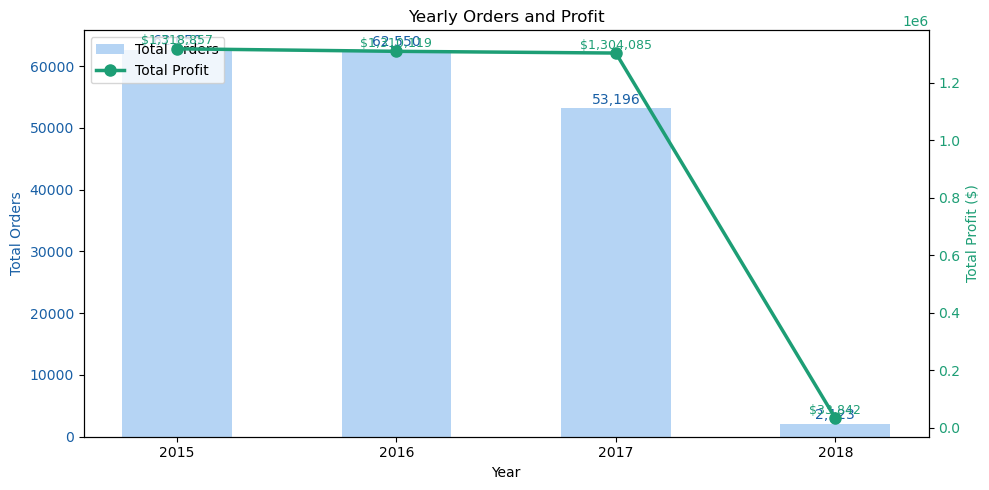

In [13]:
SELECT
    YEAR([order_date_clean]) AS yr,
    MONTH([order_date_clean]) AS mo,
    FORMAT(COUNT(*), 'n0') AS mo_orders,
    FORMAT(SUM([Order Profit Per Order]),'n1') AS mo_profit,
    FORMAT(SUM(Sales),'n1') AS mo_sales
FROM vw_financial_orders
GROUP BY YEAR([order_date_clean]), MONTH([order_date_clean])
ORDER BY YEAR([order_date_clean]), MONTH([order_date_clean])

(37 rows affected)

yr   | mo | mo_orders | mo_profit | mo_sales   
-----+----+-----------+-----------+------------
2015 | 1  | 5,064     | 104,174.7 | 999,906.7  
2015 | 2  | 4,434     | 90,796.9  | 870,918.2  
2015 | 3  | 5,067     | 105,569.3 | 997,759.3  
2015 | 4  | 4,839     | 99,911.3  | 955,497.7  
2015 | 5  | 5,038     | 109,526.9 | 986,553.8  
2015 | 6  | 4,872     | 103,893.5 | 971,529.9  
2015 | 7  | 5,073     | 110,755.3 | 995,464.7  
2015 | 8  | 4,969     | 111,721.1 | 972,559.5  
2015 | 9  | 4,874     | 108,039.6 | 966,601.0  
2015 | 10 | 5,027     | 95,440.5  | 996,632.5  
2015 | 11 | 4,967     | 98,954.2  | 979,705.4  
2015 | 12 | 5,094     | 103,879.8 | 1,002,175.4
2016 | 1  | 5,052     | 102,610.8 | 997,161.9  
2016 | 2  | 4,630     | 81,455.9  | 919,528.2  
2016 | 3  | 4,948     | 97,321.2  | 972,947.4  
2016 | 4  | 4,844     | 107,763.5 | 948,878.7  
2016 | 5  | 4,980     | 104,389.4 | 965,432.8  
2016 | 6  | 4,790     | 101,426.3 | 950,564.4  
2016 | 7  | 4,925     | 112,909.7 | 974,

### The real problem starts to raise here 
There is a significant continuous drop profit and sales starting form october-2017.\
the python chart below confirm this finding visually. 

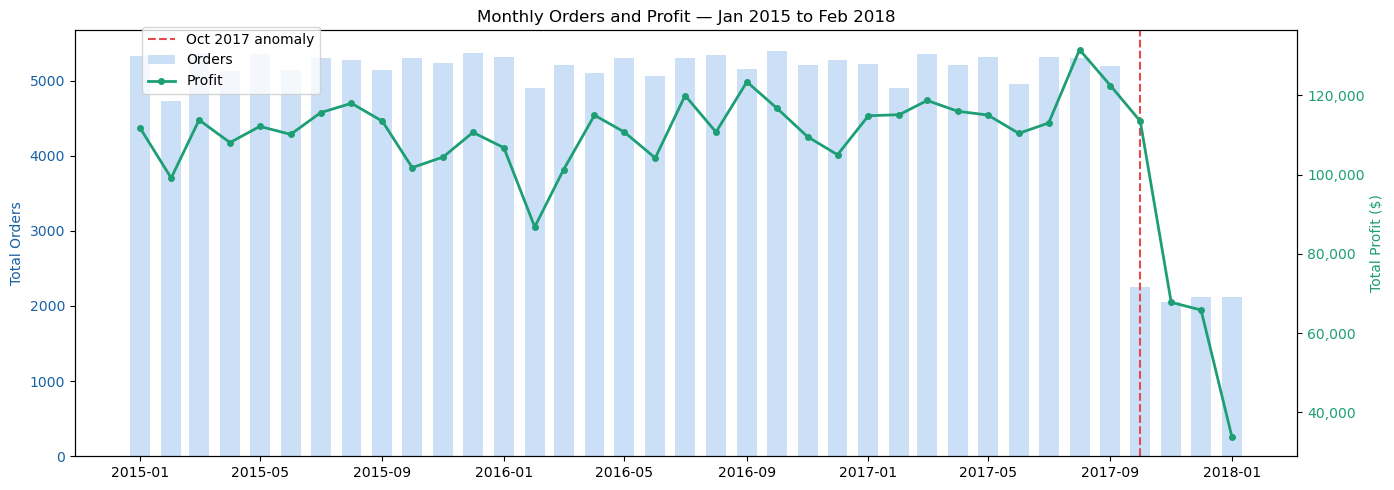

## 5. The October 2017 Anomaly

In [ ]:
SELECT
    YEAR(order_date_clean) AS yr,
    COUNT(*) AS total_order,
    FORMAT(SUM([Order Profit Per Order]),'n2') AS October_profit
FROM vw_financial_orders
WHERE MONTH(order_date_clean) = 10
GROUP BY YEAR(order_date_clean)
ORDER BY YEAR(order_date_clean)

(3 rows affected)

yr   | total_order | October_profit
-----+-------------+---------------
2015 | 5027        | 95,440.52     
2016 | 5165        | 109,622.66    
2017 | 2145        | 110,629.91    
(3 rows)

In [19]:
SELECT
    YEAR(order_date_clean) AS yr,
    MONTH(order_date_clean) AS mo,
    DAY(order_date_clean) AS day_,
    COUNT(*) AS day_orders,
    SUM([Order Profit Per Order]) AS day_profit
FROM dataco_clean
WHERE YEAR(order_date_clean) >= 2017 AND MONTH(order_date_clean) > 8
GROUP BY MONTH(order_date_clean), DAY(order_date_clean), YEAR(order_date_clean)
ORDER BY MONTH(order_date_clean), DAY(order_date_clean), YEAR(order_date_clean)
-- For every day after 2nd October the total count of order per day is 68 or 69
-- This is fetal data issue, these records are mostly AI generated that can't be included in further analysis in PowerBI

(122 rows affected)

yr   | mo | day_ | day_orders | day_profit         
-----+----+------+------------+--------------------
2017 | 9  | 1    | 180        | 5193.860000000001  
2017 | 9  | 2    | 173        | 5008.470000000002  
2017 | 9  | 3    | 183        | 5020.849999999999  
2017 | 9  | 4    | 163        | 2715.5200000000013 
2017 | 9  | 5    | 178        | 2701.1399999999994 
2017 | 9  | 6    | 165        | 3820.639999999999  
2017 | 9  | 7    | 146        | 3510.4             
2017 | 9  | 8    | 168        | 3259.7300000000005 
2017 | 9  | 9    | 175        | 5623.21            
2017 | 9  | 10   | 186        | 3154.1299999999997 
2017 | 9  | 11   | 190        | 6194.0499999999965 
2017 | 9  | 12   | 190        | 3468.340000000001  
2017 | 9  | 13   | 180        | 3693.8799999999974 
2017 | 9  | 14   | 172        | 2272.0700000000006 
2017 | 9  | 15   | 165        | 474.2500000000008  
2017 | 9  | 16   | 170        | 7270.1900000000005 
2017 | 9  | 17   | 177        | 4518.590000000004  
2017 | 9  | 

Fake data discovered. Real data ends Oct 2 2017. Pattern: exactly 68-69 orders/day for 91 days

## 6. Catalog Expansion Discovery
How October investigation led to this finding

In [4]:
SELECT
    [Category Name],
    MIN(YEAR(order_date_clean)) launch_yr,
    MIN(MONTH(order_date_clean)) launch_mo,
    SUM([Order Profit Per Order]) total_profit
FROM dataco_clean
GROUP BY [Category Name]

(50 rows affected)

Category Name        | launch_yr | launch_mo | total_profit      
---------------------+-----------+-----------+-------------------
Children's Clothing  | 2017      | 10        | 27178.09999999999 
Crafts               | 2017      | 11        | 25531.170000000002
CDs                  | 2017      | 10        | 383.85            
Basketball           | 2017      | 9         | 1845.6700000000003
DVDs                 | 2017      | 1         | 6655.429999999998 
Baby                 | 2017      | 10        | 1525.0300000000007
Books                | 2017      | 10        | 883.0099999999999 
As Seen on  TV!      | 2017      | 4         | 714.4300000000001 
Accessories          | 2015      | 1         | 16643.519999999997
Computers            | 2017      | 10        | 69656.80999999998 
Fitness Accessories  | 2015      | 1         | 5258.39           
Consumer Electronics | 2017      | 10        | 13223.400000000001
Girls' Apparel       | 2015      | 1         | 17288.57          
Golf Appar

In [1]:
WITH category_cohort AS (
    SELECT
        [Category Name],
        MIN(order_date_clean) AS first_order_date,
        YEAR(MIN(order_date_clean)) AS launch_year
    FROM dataco_clean
    WHERE order_date_clean IS NOT NULL
    GROUP BY [Category Name]
),
category_with_cohort AS (
    SELECT
        d.[Category Name],
        d.order_date_clean,
        CASE
            WHEN c.launch_year = 2015 THEN 'Established'
            ELSE 'New'
        END AS cohort
    FROM dataco_clean d
    JOIN category_cohort c ON c.[Category Name] = d.[Category Name]
    WHERE d.order_date_clean IS NOT NULL
)
SELECT
    YEAR(order_date_clean) AS yr,
    MONTH(order_date_clean) AS mo,
    SUM(CASE WHEN cohort = 'Established' THEN 1 ELSE 0 END) AS established_items,
    SUM(CASE WHEN cohort = 'New'         THEN 1 ELSE 0 END) AS new_items,
    COUNT(*) AS total_items
FROM category_with_cohort
GROUP BY
    YEAR(order_date_clean),
    MONTH(order_date_clean)
ORDER BY yr, mo;

-- Noted here, starting from Aril-2017 new categories started to appear till October of the same year where the fake data and sales volume drops

(37 rows affected)

yr   | mo | established_items | new_items | total_items
-----+----+-------------------+-----------+------------
2015 | 1  | 5322              | 0         | 5322       
2015 | 2  | 4729              | 0         | 4729       
2015 | 3  | 5362              | 0         | 5362       
2015 | 4  | 5126              | 0         | 5126       
2015 | 5  | 5357              | 0         | 5357       
2015 | 6  | 5134              | 0         | 5134       
2015 | 7  | 5299              | 0         | 5299       
2015 | 8  | 5273              | 0         | 5273       
2015 | 9  | 5140              | 0         | 5140       
2015 | 10 | 5302              | 0         | 5302       
2015 | 11 | 5235              | 0         | 5235       
2015 | 12 | 5371              | 0         | 5371       
2016 | 1  | 5317              | 0         | 5317       
2016 | 2  | 4894              | 0         | 4894       
2016 | 3  | 5210              | 0         | 5210       
2016 | 4  | 5097            

**Adding category release date**\
assuming first order date as the release date

In [ ]:
ALTER TABLE dataco_clean
ADD launch_year INT

(Command completed successfully)

In [2]:
WITH get_date AS(
    SELECT
        [product name],
        MIN(YEAR(order_date_clean)) release_date
    FROM dataco_clean
    GROUP BY [product name]
)
UPDATE d
SET d.launch_year = g.release_date
FROM dataco_clean d
JOIN get_date g ON d.[product name] = g.[product name]

(180519 rows affected)

## 7. Vintage Cohort Analysis

In [ ]:
with cat_launch as (
    SELECT
        [Category Name] as cat_name,
        [Product Name] product,
        MIN(YEAR(order_date_clean)) launch_yr,
        MIN(MONTH(order_date_clean)) launch_mo
    FROM dataco_clean
    GROUP BY [Product Name],[Category Name]
)
select
    launch_mo,
    launch_yr,
    APPROX_COUNT_DISTINCT(cat_name) AS category_launched,
    COUNT(*) AS products_launched
from cat_launch
group by launch_yr, launch_mo

-- Very impulsive behavior in new categories and products launching, 24 chuck of categories, 52 products in the same year and the same month
-- Our pivot point of data (october-2017) where all metrics collapse and dll our data is considered fake or AI generated has chunk release for whole new 7 categories. this is untraditional business behavior

(6 rows affected)

launch_mo | launch_yr | category_launched | products_launched
----------+-----------+-------------------+------------------
1         | 2015      | 24                | 54               
1         | 2017      | 10                | 10               
4         | 2017      | 16                | 33               
9         | 2017      | 8                 | 13               
10        | 2017      | 7                 | 7                
11        | 2017      | 1                 | 1                
(6 rows)

In [ ]:
SELECT
    CASE
        WHEN order_date_clean < '2017-10-01' THEN 'Before Oct 2017'
        ELSE 'After Oct 2017'
    END AS period,
    COUNT(*) AS total_orders,
    COUNT(*) / DATEDIFF(MONTH,
        MIN(order_date_clean),
        MAX(order_date_clean)
    ) AS avg_orders_per_month
FROM dataco_clean
WHERE order_date_clean IS NOT NULL
GROUP BY
    CASE
        WHEN order_date_clean < '2017-10-01' THEN 'Before Oct 2017'
        ELSE 'After Oct 2017'
    END
-- Further year categories in the next query

(2 rows affected)

period          | total_orders | avg_orders_per_month
----------------+--------------+---------------------
After Oct 2017  | 8557         | 2852                
Before Oct 2017 | 171962       | 5373                
(2 rows)

In [4]:
WITH category_performance AS (
    SELECT
        [Category Name],
        MIN(YEAR(TRY_CAST([order date (DateOrders)] AS DATE))) AS launch_year,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN [Order Profit Per Order] < 0 THEN 1 ELSE 0 END) AS losing_orders,
        AVG(CAST([Order Profit Per Order] AS FLOAT)) AS avg_profit,
        AVG(CAST([Order Item Discount Rate] AS FLOAT)) AS avg_discount,
        1.0 * SUM(CASE WHEN [Order Profit Per Order] < 0 THEN 1 ELSE 0 END) / COUNT(*) AS loss_rate
    FROM dataco_clean
    GROUP BY [Category Name]
),
median_prep AS (
    -- Calculate the Median here using the Window Function
    SELECT
        *,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_orders)
            OVER(PARTITION BY launch_year) AS median_val
    FROM category_performance
)
SELECT
    launch_year,
    COUNT(*) AS category_count,
    MAX(median_val) AS Median_Orders,
    FORMAT(SUM(total_orders), 'n0') AS total_orders_sum,
    FORMAT(AVG(total_orders * 1.0), 'n1') AS avg_orders_per_category,
    FORMAT(AVG(avg_profit), 'n') AS avg_profit_per_order,
    FORMAT(AVG(loss_rate), 'p') AS avg_loss_rate_pct,
    FORMAT(STDEV(loss_rate), 'p') AS loss_rate_std_dev,
    FORMAT(MIN(loss_rate), 'p') AS min_loss_rate,
    FORMAT(MAX(loss_rate), 'p') AS max_loss_rate
FROM median_prep
GROUP BY launch_year
ORDER BY launch_year;

-- Year launch analysis shows big difference between the categories launched in 2015 and categories launched in 2017
-- new products tends to be less mature with low demand and also can't be predicted as accurate as the old ones (loss rate SD for new ~ 3 times the old ones)
-- Some products have very low demand that makes the los rate analysis is not reliable

(2 rows affected)

launch_year | category_count | Median_Orders | total_orders_sum | avg_orders_per_category | avg_profit_per_order | avg_loss_rate_pct | loss_rate_std_dev | min_loss_rate | max_loss_rate
------------+----------------+---------------+------------------+-------------------------+----------------------+-------------------+-------------------+---------------+--------------
2015        | 24             | 1338          | 170,905          | 7,121.0                 | 17.08                | 18.55%            | 1.07%             | 16.18%        | 21.18%       
2017        | 26             | 394.5         | 9,614            | 369.8                   | 28.59                | 18.05%            | 3.07%             | 9.84%         | 24.04%       
(2 rows)

In [3]:
SELECT
    [Category Name],
    MIN(YEAR(order_date_clean)) AS launch_year,
    COUNT(*) AS total_orders,
    CASE
        WHEN COUNT(*) < 100  THEN 'Insufficient sample'
        WHEN COUNT(*) < 500  THEN 'Low confidence'
        WHEN COUNT(*) < 1000 THEN 'Moderate confidence'
        ELSE                      'High confidence'
    END AS statistical_confidence,
    FORMAT(1.0 * SUM(CASE WHEN [Order Profit Per Order] < 0
                        THEN 1 ELSE 0 END) / COUNT(*) , 'p') AS loss_rate_pct
FROM dataco_clean
GROUP BY [Category Name]
ORDER BY
    MIN(YEAR(order_date_clean)),
    COUNT(*) DESC;

(50 rows affected)

Category Name        | launch_year | total_orders | statistical_confidence | loss_rate_pct
---------------------+-------------+--------------+------------------------+--------------
Cleats               | 2015        | 24551        | High confidence        | 18.70%       
Men's Footwear       | 2015        | 22246        | High confidence        | 18.74%       
Women's Apparel      | 2015        | 21035        | High confidence        | 18.65%       
Indoor/Outdoor Games | 2015        | 19298        | High confidence        | 18.74%       
Fishing              | 2015        | 17325        | High confidence        | 18.52%       
Water Sports         | 2015        | 15540        | High confidence        | 18.82%       
Camping & Hiking     | 2015        | 13729        | High confidence        | 18.87%       
Cardio Equipment     | 2015        | 12487        | High confidence        | 18.68%       
Shop By Sport        | 2015        | 10984        | High confidence        | 19.61%       

Finding:\
26 out of 50 product (52% of products) are new products(less than 1 year in market). Eight products out of this are in the unreliable date range (October-2017)\
Three expansion waves. 18 of 26 new categories have under 3 months real data

**cohort label**\
Adding cohort label to indicate (Established/ New)

In [5]:
ALTER TABLE dataco_clean
ADD cohort_label NVARCHAR(20)

Commands completed successfully.

In [ ]:

WITH set_label AS (
    SELECT
        [Product Name],
        (CASE WHEN MIN(YEAR(order_date_clean)) = 2015 THEN 'Established' ELSE 'New' END) label_logic
    FROM dataco_clean
    GROUP BY [Product Name]
    )
UPDATE d
SET d.cohort_label = l.label_logic
FROM dataco_clean d
JOIN set_label l ON l.[Product Name] = d.[Product Name]

(Command completed successfully)

## 8. Seasonality Index

In [8]:
WITH monthly_indices AS (
    SELECT
        [Category Name] AS category,
        YEAR(order_date_clean) AS yr,
        MONTH(order_date_clean) AS mo,
        COUNT(*) * 1.0 / AVG(COUNT(*) * 1.0) OVER(PARTITION BY [Category Name], YEAR(order_date_clean)) AS s_index_yr
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
    AND [Category Name] IN (
        SELECT [Category Name] FROM dataco_clean
        GROUP BY [Category Name] HAVING MIN(YEAR(order_date_clean)) = 2015
    )
    GROUP BY [Category Name], YEAR(order_date_clean), MONTH(order_date_clean)
)
SELECT
    category,
    mo,
    format(AVG(s_index_yr),'n') AS s_index
FROM monthly_indices
GROUP BY category, mo
ORDER BY category, mo

(288 rows affected)

category             | mo | s_index
---------------------+----+--------
Accessories          | 1  | 0.98   
Accessories          | 2  | 0.90   
Accessories          | 3  | 1.05   
Accessories          | 4  | 0.96   
Accessories          | 5  | 1.15   
Accessories          | 6  | 0.94   
Accessories          | 7  | 1.01   
Accessories          | 8  | 0.88   
Accessories          | 9  | 0.95   
Accessories          | 10 | 1.08   
Accessories          | 11 | 1.11   
Accessories          | 12 | 1.04   
Baseball & Softball  | 1  | 1.08   
Baseball & Softball  | 2  | 0.97   
Baseball & Softball  | 3  | 1.21   
Baseball & Softball  | 4  | 1.17   
Baseball & Softball  | 5  | 1.10   
Baseball & Softball  | 6  | 0.72   
Baseball & Softball  | 7  | 1.29   
Baseball & Softball  | 8  | 0.71   
Baseball & Softball  | 9  | 0.83   
Baseball & Softball  | 10 | 0.85   
Baseball & Softball  | 11 | 0.92   
Baseball & Softball  | 12 | 1.12   
Boxing & MMA         | 1  | 0.77   
Boxing & MMA         | 2  | 

Top 10 performing products (profit wise after trimming any transaction after 30-9-2017)\
\
\
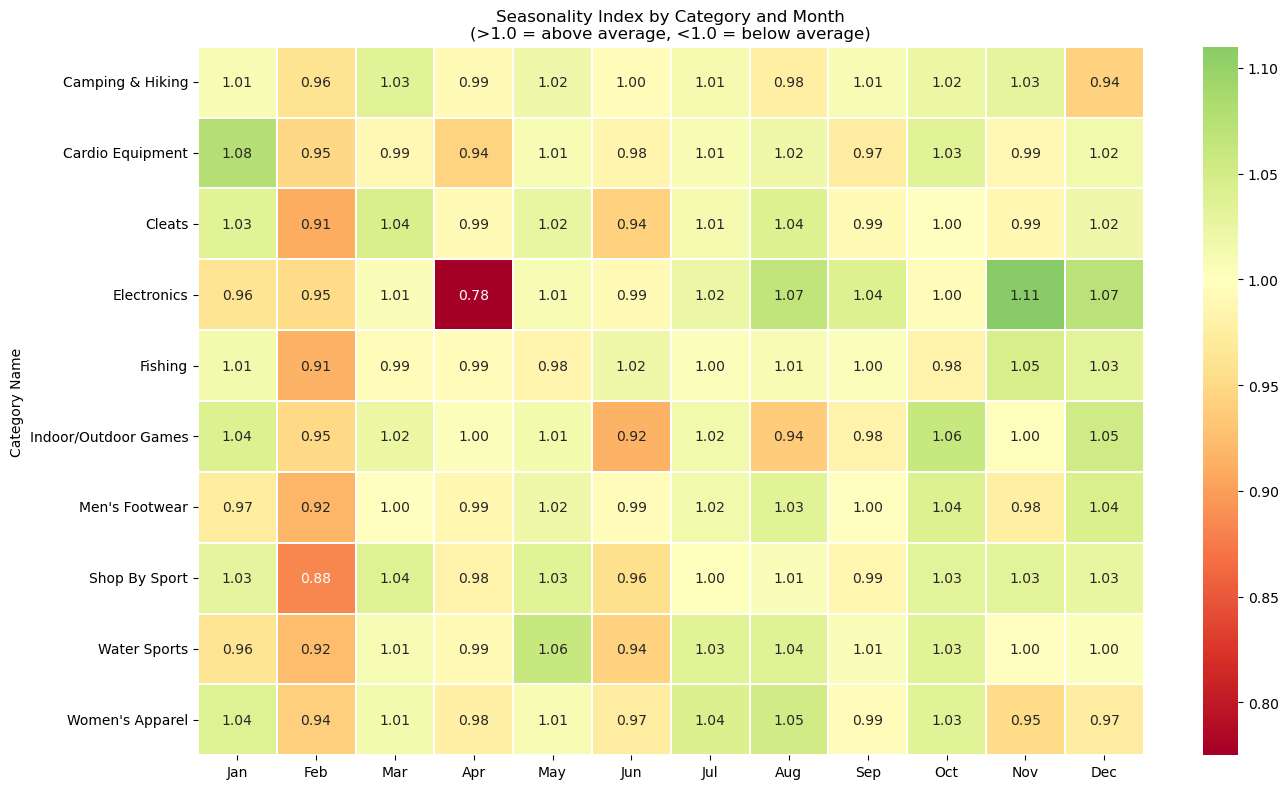

Steady demand across the year, No further seasonality analysis needed.

## 9. Data Quality Finding

### Further visual analysis will be based only on data before October-2017

Creating views for healthy data

In [ ]:
CREATE OR ALTER VIEW vw_operational_clean AS
SELECT * FROM dataco_clean
WHERE order_date_clean < '2017-10-01'

Commands completed successfully.

In [ ]:
CREATE OR ALTER VIEW vw_financial_clean AS
SELECT * FROM dataco_clean
WHERE [Order Status] NOT IN ('CANCELED', 'SUSPECTED_FRAUD', 'PAYMENT_REVIEW')
AND order_date_clean < '2017-10-01'

Commands completed successfully.

Quick Summary: The 2017 Catalog Expansion\
While digging into the data, I found the real reason our 2017 numbers look so strange. It turns out DataCo basically tried to double its catalog size in a single year:

The Aggressive Launch: We added 26 new categories in 2017 alone. To put that in perspective, we only had 24 established categories from 2015.

The Timeline: They didn't spread these out. They launched 7 categories in April and another 8 in October.

The "October Drop" Explained: That 30% crash we see in October? It’s probably not a drop in demand. It’s likely "operational noise" from trying to launch 8 categories at the exact same time. It probably messed up the data or overwhelmed the system.

Data Reliability: Most of these new categories (18 out of 26) have less than 3 months of data. I’ve excluded them from my main analysis because you can't build a reliable forecast on 90 days of "new launch" data.

My Take: We shouldn't judge the expansion yet. We need a full 12-month cycle to see if these new categories actually work. For now, the only "new" group worth looking at is the April cohort, since we have about 8 months of history for them.

# Post star schema analysis

**SQL scripts for Star schema creation and data pull from the main table are provided in 'Scripts' folder**

This section mainly made for visual associated columns used in PowerBi

## Overview analysis page in PowerBi 

### ABC - XYZ Analysis

#### ABC Analysis

##### Category level

In [ ]:
WITH Category_Summarization AS (
    SELECT
        [Category Id],
        [Category Name],
        SUM([Order Profit Per Order]) AS category_profit
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
    GROUP BY [Category Id], [Category Name]
),
Cumulative_Summarization AS (
    SELECT
        [Category Id],
        [Category Name],
        category_profit,
        SUM(category_profit) OVER (ORDER BY category_profit DESC) AS cumulative_profit,
        1.0 * SUM(category_profit) OVER (ORDER BY category_profit DESC) /
            SUM(category_profit) OVER () AS cumulative_pct
    FROM Category_Summarization
    WHERE category_profit > 0
)
SELECT
    [Category Id],
    [Category Name],
    cumulative_pct,
    CASE
        WHEN cumulative_pct <= 0.80 THEN 'A'
        WHEN cumulative_pct <= 0.95 THEN 'B'
        ELSE 'C'
    END AS category_segment
FROM Cumulative_Summarization
ORDER BY cumulative_pct ASC;

(32 rows affected)

Category Id | Category Name        | cumulative_pct      | category_segment
------------+----------------------+---------------------+-----------------
45          | Fishing              | 0.2047240722951911  | A               
17          | Cleats               | 0.33864111971905575 | A               
43          | Camping & Hiking     | 0.45440848142549956 | A               
9           | Cardio Equipment     | 0.5579168668944047  | A               
24          | Women's Apparel      | 0.652925423991348   | A               
48          | Water Sports         | 0.7410197993417439  | A               
46          | Indoor/Outdoor Games | 0.8273453863656905  | B               
18          | Men's Footwear       | 0.9118738871408709  | B               
29          | Shop By Sport        | 0.9470153521897916  | B               
37          | Electronics          | 0.9547805928649636  | C               
26          | Girls' Apparel       | 0.9594703034748451  | C               
40          

In [ ]:
ALTER TABLE dim_product
ADD category_segment NVARCHAR(50)

In [ ]:
WITH Category_Summarization AS (
    SELECT
        [Category Id],
        [Category Name],
        COUNT([Product Card Id]) AS category_sales
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
    GROUP BY [Category Id], [Category Name]
),
Cumulative_Summarization AS (
    SELECT
        [Category Id],
        [Category Name],
        category_sales,
        SUM(category_sales) OVER (ORDER BY category_sales DESC) AS cumulative_sales,
        1.0 * SUM(category_sales) OVER (ORDER BY category_sales DESC) /
            SUM(category_sales) OVER () AS cumulative_pct
    FROM Category_Summarization
),segment_label AS(
    SELECT
        [Category Id],
        [Category Name],
        cumulative_pct,
        CASE
            WHEN cumulative_pct <= 0.80 THEN 'A'
            WHEN cumulative_pct <= 0.95 THEN 'B'
            ELSE 'C'
        END AS category_segment
    FROM Cumulative_Summarization)
UPDATE p
SET p.category_segment = s.category_segment
FROM segment_label s
JOIN dim_product p
    ON s.[Category Id] = p.category_id


#### Product level

In [1]:
WITH product_list AS (
    SELECT
        [Product Name],
        SUM([Order Profit Per Order]) AS product_profit
    FROM vw_financial_clean
    GROUP BY [Product Name]
), cumulative AS(
SELECT
    [Product Name],
    product_profit,
    SUM(product_profit) OVER (ORDER BY product_profit DESC) /
    SUM(product_profit) OVER () as cumulative_percent
FROM product_list
WHERE product_profit > 0
)
SELECT
    [Product Name],
    (CASE
        WHEN cumulative_percent < 0.70 THEN 'A'
        WHEN cumulative_percent < 0.95 THEN 'B'
        ELSE 'C'
    END) AS Segment
FROM cumulative
order by Segment

(98 rows affected)

Product Name                                  | Segment
----------------------------------------------+--------
Field & Stream Sportsman 16 Gun Fire Safe     | A      
Perfect Fitness Perfect Rip Deck              | A      
Diamondback Women's Serene Classic Comfort Bi | A      
Nike Men's Free 5.0+ Running Shoe             | A      
Nike Men's Dri-FIT Victory Golf Polo          | A      
Pelican Sunstream 100 Kayak                   | B      
O'Brien Men's Neoprene Life Vest              | B      
Nike Men's CJ Elite 2 TD Football Cleat       | B      
Under Armour Girls' Toddler Spine Surge Runni | B      
adidas Men's F10 Messi TRX FG Soccer Cleat    | B      
adidas Youth Germany Black/Red Away Match Soc | B      
LIJA Women's Eyelet Sleeveless Golf Polo      | B      
Titleist Pro V1x High Numbers Personalized Go | C      
Nike Men's Comfort 2 Slide                    | C      
Titleist Pro V1 High Numbers Personalized Gol | C      
Under Armour Women's Micro G Skulpt Running S | 

In [ ]:
-- creating ABC labeling column

ALTER TABLE dim_product
ADD ABC_segment nvarchar(50)

Commands completed successfully.

In [ ]:
WITH product_list AS (
    SELECT [Product Name], SUM([Order Profit Per Order]) AS profit
    FROM vw_financial_clean GROUP BY [Product Name]
),
cumulative AS (
    SELECT [Product Name],
    SUM(profit) OVER (ORDER BY profit DESC) / NULLIF(SUM(profit) OVER (), 0) as cum_percent
    FROM product_list WHERE profit > 0
),
pro_segment AS (
    SELECT [Product Name],
    -- FORCE the CTE to use NVARCHAR(50) for every single row
    CAST(CASE
    WHEN cumulative_percent < 0.70 THEN 'A'
    WHEN cumulative_percent < 0.95 THEN 'B'
    ELSE 'C'
    END AS NVARCHAR(50)) AS Segment
    FROM cumulative
)
UPDATE p
SET p.ABC_segment = ISNULL(s.Segment, CAST('LOSS GENERATING' AS NVARCHAR(50)))
FROM dim_product p
LEFT JOIN pro_segment s ON s.[Product Name] = p.product_name
WHERE EXISTS (
    SELECT 1 FROM dataco_clean d
    WHERE d.[Product Name] = p.product_name AND d.order_date_clean < '2017-10-01'
);

#### XYZ Analysis 

In [ ]:
-- 1. Find the first year/month for every product
WITH product_birth AS (
    SELECT
        [Product Name],
        MIN(YEAR(order_date_clean)) AS birth_yr,
        MIN(MONTH(order_date_clean)) AS birth_mo
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
    GROUP BY [Product Name]
),

-- 2. Get a list of all unique months in our period
calendar AS (
    SELECT DISTINCT
        MONTH(order_date_clean) AS C_mo,
        YEAR(order_date_clean) AS C_yr
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
),

-- 3. Create the "Expected Timeline" for each product
product_mapping AS (
    SELECT
        b.[Product Name],
        c.C_yr,
        c.C_mo
    FROM product_birth b
    CROSS JOIN calendar c
    WHERE (c.C_yr > b.birth_yr)
    OR (c.C_yr = b.birth_yr AND c.C_mo >= b.birth_mo)
),

-- 4. Summarize actual monthly sales from the data
monthly_sales AS (
    SELECT
        [Product Name],
        YEAR(order_date_clean) AS S_yr,
        MONTH(order_date_clean) AS S_mo,
        COUNT(*) AS actual_orders
    FROM dataco_clean
    WHERE order_date_clean < '2017-10-01'
    GROUP BY [Product Name], YEAR(order_date_clean), MONTH(order_date_clean)
)

-- 5. The Final Calculation
SELECT
    p.[Product Name],
    COUNT(*) AS Months_Count, -- Counts total months the product existed
    FORMAT(AVG(CAST(ISNULL(s.actual_orders, 0) AS FLOAT)),'n') AS Avg_Monthly_Sales,
    FORMAT(STDEVP(ISNULL(s.actual_orders, 0)),'n') AS Demand_Volatility,
    -- CV Calculation (Volatility / Average)
    FORMAT(STDEVP(ISNULL(s.actual_orders, 0)) / NULLIF(AVG(CAST(ISNULL(s.actual_orders, 0) AS FLOAT)), 0),'n4') AS CV,
    -- XYZ Segmentation
    CASE
        WHEN STDEVP(ISNULL(s.actual_orders, 0)) / NULLIF(AVG(CAST(ISNULL(s.actual_orders, 0) AS FLOAT)), 0) < 0.2 THEN 'X'
        WHEN STDEVP(ISNULL(s.actual_orders, 0)) / NULLIF(AVG(CAST(ISNULL(s.actual_orders, 0) AS FLOAT)), 0) < 0.5 THEN 'Y'
        ELSE 'Z'
    END AS XYZ_Category
FROM product_mapping p
LEFT JOIN monthly_sales s ON  -- To force the zero sales month for each product to be considered in calculations
    p.[Product Name] = s.[Product Name]
AND p.C_yr = s.S_yr
AND p.C_mo = s.S_mo
GROUP BY p.[Product Name]
ORDER BY CV ASC;

(100 rows affected)

Product Name                                  | Months_Count | Avg_Monthly_Sales  | Demand_Volatility  | CV                   | XYZ_Category
----------------------------------------------+--------------+--------------------+--------------------+----------------------+-------------
Bowflex SelectTech 1090 Dumbbells             | 1            | 7                  | 0                  | 0                    | X           
Bushnell Pro X7 Jolt Slope Rangefinder        | 1            | 4                  | 0                  | 0                    | X           
Diamondback Boys' Insight 24 Performance Hybr | 1            | 29                 | 0                  | 0                    | X           
Diamondback Girls' Clarity 24 Hybrid Bike 201 | 1            | 28                 | 0                  | 0                    | X           
Garmin Approach S4 Golf GPS Watch             | 1            | 36                 | 0                  | 0                    | X           
Garmin Foreru

In [ ]:
-- Creating the new column of XYZ segmentation label and number of months of product availability

ALTER TABLE dim_product
ADD XYZ_segment NVARCHAR(10)

In [ ]:
WITH Product_Timeline AS (
    SELECT
        [Product Name],
        MIN(YEAR(order_date_clean)) AS Start_Year,
        MIN(MONTH(order_date_clean)) AS Start_Month
    FROM dataco_clean
    WHERE order_date_clean <= '2017-09-30'
    GROUP BY [Product Name]
),
Month_List AS (
    SELECT DISTINCT
        YEAR(order_date_clean) AS Cal_Year,
        MONTH(order_date_clean) AS Cal_Month
    FROM dataco_clean
    WHERE order_date_clean <= '2017-09-30'
),
Grid AS (
    SELECT
        p.[Product Name],
        m.Cal_Year,
        m.Cal_Month
    FROM Product_Timeline p
    CROSS JOIN Month_List m
    WHERE (m.Cal_Year > p.Start_Year)
    OR (m.Cal_Year = p.Start_Year AND m.Cal_Month >= p.Start_Month)
),
Actual_Sales AS (
    SELECT
        [Product Name],
        YEAR(order_date_clean) AS S_Year,
        MONTH(order_date_clean) AS S_Month,
        COUNT(*) AS Sales_Count
    FROM dataco_clean
    WHERE order_date_clean <= '2017-09-30'
    GROUP BY [Product Name], YEAR(order_date_clean), MONTH(order_date_clean)
),
XYZ_Math AS (
    SELECT
        g.[Product Name],
        COUNT(*) AS Total_Months,
        (STDEVP(ISNULL(s.Sales_Count, 0)) / NULLIF(AVG(CAST(ISNULL(s.Sales_Count, 0) AS FLOAT)), 0)) AS CV
    FROM Grid g
    LEFT JOIN Actual_Sales s ON g.[Product Name] = s.[Product Name]
                            AND g.Cal_Year = s.S_Year
                            AND g.Cal_Month = s.S_Month
    GROUP BY g.[Product Name]
),
Final_Labels AS (
    SELECT
        [Product Name],
        Total_Months,
        CASE
            WHEN CV < 0.2 THEN 'X'
            WHEN CV < 0.5 THEN 'Y'
            ELSE 'Z'
        END AS Segment
    FROM XYZ_Math
)

-- 7. EXECUTE UPDATE
UPDATE p
SET
    p.XYZ_segment = f.Segment,
    p.Months_Count = f.Total_Months
FROM dim_product p
JOIN Final_Labels f ON p.product_name = f.[Product Name];

Thresholds adjusted to X<0.2, Y<0.5, Z≥0.5 
to produce a meaningful three-segment distribution reflecting 
DataCo's actual demand variability profile.

#### Order item decomposition

**The Four Cases of order profit status** \
\
Case 1: Pure Profit Order\
All items profitable, order profitable\
→ Healthy transaction, no intervention needed\

Case 2: Contaminated Profit Order \ 
Order shows profit overall but contains loss items\
→ The loss items are HIDDEN by profitable items in the same order\
→ Most dangerous case — looks fine in aggregate, hides problems\

Case 3: Salvaged Loss Order\
Order is a loss overall but contains profitable items\
→ Profitable items are being dragged down by loss items\
→ If loss items were removed, order would be profitable

Case 4: Pure Loss Order\
All items losses, order is a loss\
→ Complete pricing failure on this transaction\
→ Should never have been processed as structured

In [5]:
-- Selecting the each order and its orders, labeling the losing products within the order
WITH product_level AS (
SELECT
	order_id,
	order_item_id,
	product_profit AS product_profit,
	SUM(product_profit) OVER (PARTITION BY order_id) AS order_profit,
	(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END) AS profitable_indicator
FROM fact_orders
)
-- full order summarization
SELECT TOP 50
	order_id,
    MAX(order_profit) AS order_profit,
	(CASE
		WHEN SUM(profitable_indicator) = COUNT(order_item_id) THEN  'Case 4: Pure Loss'
		WHEN SUM(profitable_indicator) = 0 THEN  'Case 1: Pure Profit'
		WHEN SUM(order_profit) >= 0 AND SUM(profitable_indicator) > 0 THEN 'Case 2: Contaminated Profit'
		WHEN SUM(order_profit) < 0 AND SUM(profitable_indicator) > 0 THEN 'Case 3: Salvaged Loss'
	END) AS decomposition, -- breaking down the four order cases explained before
	COUNT(order_item_id) AS total_items,
	SUM(profitable_indicator) AS losses_per_order,
	FORMAT(1.00*SUM(profitable_indicator)/COUNT(order_item_id),'p') AS loss_ratio
FROM product_level
GROUP BY order_id
ORDER BY decomposition DESC, order_profit

(50 rows affected)

order_id | order_profit        | decomposition     | total_items | losses_per_order | loss_ratio
---------+---------------------+-------------------+-------------+------------------+-----------
41576    | -1831.46            | Case 4: Pure Loss | 5           | 5                | 100.00%   
27359    | -1678.6             | Case 4: Pure Loss | 3           | 3                | 100.00%   
10989    | -1638.9300000000003 | Case 4: Pure Loss | 3           | 3                | 100.00%   
36376    | -1573.92            | Case 4: Pure Loss | 2           | 2                | 100.00%   
18265    | -1496.78            | Case 4: Pure Loss | 4           | 4                | 100.00%   
9834     | -1332.8000000000002 | Case 4: Pure Loss | 4           | 4                | 100.00%   
52729    | -1305.95            | Case 4: Pure Loss | 3           | 3                | 100.00%   
18631    | -1276.4             | Case 4: Pure Loss | 4           | 4                | 100.00%   
8989     |

In [ ]:
-- creating column in which the decomposition analysis will be pushed

ALTER TABLE fact_orders
ADD
        order_profit_decomposition NVARCHAR (50),
        order_profit               FLOAT,
        losses_per_order           INT

In [ ]:
WITH product_level AS (
SELECT
	order_id,
	order_item_id,
	product_profit,
	SUM(product_profit) OVER (PARTITION BY order_id) AS order_profit,
	(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END) AS loss_indicator
FROM fact_orders
),decomposition AS(
SELECT
	order_id,
	COUNT(order_item_id) AS total_items,
	MAX(order_profit) AS order_profit,
	(CASE
		WHEN SUM(loss_indicator) = COUNT(order_item_id) THEN'Case 4: Pure Loss'
		WHEN SUM(loss_indicator) = 0 THEN 'Case 1: Pure Profit'
		WHEN SUM(order_profit) >= 0 AND SUM(loss_indicator) > 0 THEN 'Case 2: Contaminated Profit'
		WHEN SUM(order_profit) < 0 AND SUM(loss_indicator) > 0 THEN 'Case 3: Salvaged Loss'
	END) AS decomposition,
	SUM(loss_indicator) AS losses_per_order
FROM product_level
GROUP BY order_id
)
UPDATE o
SET
	o.order_profit_decomposition  = d.decomposition,
	o.order_profit = d.order_profit,
	o.losses_per_order = d.losses_per_order
FROM fact_orders o
JOIN decomposition d ON o.order_id = d.order_id

### Customer analysis page

#### Customer life cycle analysis 

Customer life cycle has 5 cases:

1. **New customer**         ---> Joined within the latest calendar year (>= 2017-01-01).
2. **churned**              ---> No sales recorded for > 180 days relative to the data edge (whatever this customer is new or not).
3. **Dormant/Occasional**   ---> Tenure >= 2 Quarters, but total sales <= 2.
4. **Loyal**                ---> Activity Rate >= 75% (Ordered in 3 out of every 4 quarters of their tenure).
5. **Established**          ---> Joined before the latest year (< 2017) and remains active.  

In [7]:
DECLARE @AnchorDate DATE;
SELECT @AnchorDate = MAX(full_date) FROM dim_date;

WITH raw_behavior AS (
    SELECT
        f.customer_key,
        MIN(d.full_date) AS first_purchase,
        MAX(d.full_date) AS last_purchase,
        COUNT(DISTINCT f.order_id) AS total_orders,
        COUNT(DISTINCT (YEAR(d.full_date) * 10) + d.quarter) AS unique_quarters_active,
        -- How many total quarters have passed since they joined?
        DATEDIFF(QUARTER, MIN(d.full_date), MAX(d.full_date)) + 1 AS tenure_quarters,
        DATEDIFF(WEEK, MIN(d.full_date), MAX(d.full_date)) AS tenure_weeks
    FROM fact_orders f
    JOIN dim_date d ON f.date_key = d.date_key
    GROUP BY f.customer_key
),
calculated_metrics AS (
    SELECT
        *,
        DATEDIFF(DAY, last_purchase, @AnchorDate) AS days_silent,
        CAST(unique_quarters_active AS DECIMAL(5,2)) / tenure_quarters AS activity_rate
    FROM raw_behavior
) -- Selecting data sample with the calculated metrics and the lifecycle segmentation logic
SELECT TOP 100
    customer_key,
    total_orders,
    days_silent,
    tenure_quarters,
    tenure_weeks,
    activity_rate,
    CASE
        WHEN days_silent > 180 THEN 'Churned'
        WHEN first_purchase >= '2017-01-01' THEN 'New'
        WHEN tenure_quarters >= 4 AND activity_rate >= 0.75 THEN 'Loyal'
        WHEN tenure_quarters >= 2 AND total_orders <= 2 THEN 'Dormant'
        ELSE 'Established'
    END AS Customer_lifecycle_segment
FROM calculated_metrics
ORDER BY activity_rate DESC;

(100 rows affected)

customer_key | total_orders | days_silent | tenure_quarters | tenure_weeks | activity_rate   | Customer_lifecycle_segment
-------------+--------------+-------------+-----------------+--------------+-----------------+---------------------------
1687         | 3            | 533         | 2               | 14           | 1.0000000000000 | Churned                   
10330        | 2            | 204         | 2               | 19           | 1.0000000000000 | Churned                   
3024         | 2            | 496         | 2               | 11           | 1.0000000000000 | Churned                   
7623         | 3            | 865         | 2               | 15           | 1.0000000000000 | Churned                   
7905         | 1            | 145         | 1               | 0            | 1.0000000000000 | New                       
5459         | 2            | 493         | 2               | 19           | 1.0000000000000 | Churned                   
628

In [ ]:
ALTER TABLE dim_customer
ADD
    customer_life_cycle VARCHAR(50),
    activity_rate DECIMAL(5,2),
    recency_days INT,
    tenure_quarters INT,
    tenure_weeks INT

In [ ]:
-- Define the anchor date (The "Today" of the DataCo dataset)
DECLARE @AnchorDate DATE;
SELECT @AnchorDate = MAX(full_date) FROM dbo.dim_date;

WITH raw_behavior AS (
    SELECT
        f.customer_key,
        MIN(d.full_date) AS first_order,
        MAX(d.full_date) AS last_order,
        COUNT(DISTINCT f.order_id) AS total_orders,
        COUNT(DISTINCT (YEAR(d.full_date) * 10) + d.quarter) AS unique_quarters_active,
        DATEDIFF(QUARTER, MIN(d.full_date), MAX(d.full_date)) + 1 AS tenure_quarters,
        DATEDIFF(WEEK, MIN(d.full_date), MAX(d.full_date)) AS tenure_weeks
    FROM fact_orders f
    JOIN dim_date d ON f.date_key = d.date_key
    GROUP BY f.customer_key
),
calculated_metrics AS (
    SELECT
        *,
        DATEDIFF(DAY, last_order, @AnchorDate) AS days_silent,
        CAST(unique_quarters_active AS DECIMAL(5,2)) / NULLIF(tenure_quarters, 0) AS calculated_activity_rate
    FROM raw_behavior
)
UPDATE c
SET
    c.recency_days = b.days_silent,
    c.tenure_quarters = b.tenure_quarters,
    c.tenure_weeks = b.tenure_weeks,
    c.activity_rate = b.calculated_activity_rate,
    c.customer_life_cycle = CASE
        WHEN b.days_silent > 180 THEN 'Churned'
        WHEN b.first_order >= '2017-01-01' THEN 'New'
        WHEN b.tenure_quarters >= 4 AND b.calculated_activity_rate >= 0.75 THEN 'Loyal'
        WHEN b.tenure_quarters >= 2 AND b.total_orders <= 2 THEN 'Dormant'
        ELSE 'Established'
    END
FROM dim_customer c
JOIN calculated_metrics b ON c.customer_key = b.customer_key;

**For PowerBi lifecycle sort, additional helper sort column is created**

In [ ]:
ALTER TABLE dim_customer ADD lifecycle_sort_order INT;

UPDATE dim_customer
SET lifecycle_sort_order =
    CASE customer_life_cycle
        WHEN 'Loyal'       THEN 1
        WHEN 'Established' THEN 2
        WHEN 'New'         THEN 3
        WHEN 'Dormant'     THEN 4
        WHEN 'Churned'     THEN 5
        ELSE 6
    END;

In [2]:
SELECT
    customer_life_cycle,
    COUNT(*) AS customer_count,
    FORMAT(1.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 'p') AS pct,
    ROUND(AVG(activity_rate), 2) AS avg_activity_rate,
    ROUND(AVG(recency_days), 0) AS avg_days_since_last_order
FROM dim_customer
WHERE customer_life_cycle IS NOT NULL
GROUP BY customer_life_cycle
ORDER BY MIN(lifecycle_sort_order)

(5 rows affected)

customer_life_cycle | customer_count | pct    | avg_activity_rate | avg_days_since_last_order
--------------------+----------------+--------+-------------------+--------------------------
Loyal               | 403            | 3.27%  | 0.810000          | 88                       
Established         | 6003           | 48.69% | 0.480000          | 77                       
New                 | 235            | 1.91%  | 0.950000          | 77                       
Dormant             | 359            | 2.91%  | 0.330000          | 87                       
Churned             | 5330           | 43.23% | 0.640000          | 377                      
(5 rows)

Total execution time: 00:00:00.076

The vast majority of DataCo's "stable" customer base
is coasting at 48% activity — ordering sporadically,
not consistently engaged. Only 403 customers show
loyalty behavior.
\
Combined with 43% churn rate — DataCo has a customer
retention problem hiding behind stable-looking order volumes.

#### non-revenue customer analysis

In [8]:
-- Reminder :Non-revenue orders are orders with status of 'canceled', 'suspected_fraud'
WITH order_level AS (
    SELECT
        customer_key,
        order_id,
        MAX(non_revenue_flag) AS is_non_revenue
    FROM fact_orders
    GROUP BY customer_key, order_id
) -- Selecting data sample with the non-revenue order ratio and the labeling logic for non-revenue experience segmentation
SELECT TOP 100
    customer_key,
    COUNT(*) AS total_orders,
    SUM(is_non_revenue) AS non_revenue_orders,
    ROUND(1.0 * SUM(is_non_revenue) / COUNT(*), 4) AS non_revenue_ratio,
    CASE WHEN SUM(is_non_revenue) > 0
        THEN 1 ELSE 0
    END AS has_non_revenue_experience,
        CASE
            WHEN COUNT(*) = 1 AND SUM(is_non_revenue) = 1
                THEN 'Single Non-Revenue'
            WHEN COUNT(*) = 1 AND SUM(is_non_revenue) = 0
                THEN 'Single Clean Order'
            -- Multi-order cases
            WHEN SUM(is_non_revenue) = 0
                THEN 'Clean'
            WHEN 1.0 * SUM(is_non_revenue) / COUNT(*) <= 0.25
                THEN 'Low Exposure'
            WHEN 1.0 * SUM(is_non_revenue) / COUNT(*) <= 0.50
                THEN 'High Exposure'
            ELSE
                'Majority Non-Revenue'
        END AS non_revenue_label
FROM order_level
GROUP BY customer_key
ORDER BY non_revenue_ratio DESC;

(100 rows affected)

customer_key | total_orders | non_revenue_orders | non_revenue_ratio | has_non_revenue_experience | non_revenue_label   
-------------+--------------+--------------------+-------------------+----------------------------+---------------------
4348         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
3661         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
9467         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
4321         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
7434         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
8802         | 1            | 1                  | 1.000000000000    | 1                          | Single Non-Revenue  
804        

In [ ]:
ALTER TABLE dim_customer
ADD non_revenue_orders      INT,
    non_revenue_ratio       DECIMAL(5,4),
    non_revenue_label       NVARCHAR(30),
    has_non_revenue_flag    TINYINT

In [ ]:
WITH order_level AS (
    SELECT
        customer_key,
        order_id,
        MAX(non_revenue_flag) AS is_non_revenue
    FROM fact_orders
    GROUP BY customer_key, order_id
),
customer_non_revenue AS (
    SELECT
        customer_key,
        COUNT(*) AS total_orders,
        SUM(is_non_revenue) AS non_revenue_orders,
        ROUND(1.0 * SUM(is_non_revenue) / COUNT(*), 4)
            AS non_revenue_ratio,
        CASE WHEN SUM(is_non_revenue) > 0
            THEN 1 ELSE 0
        END AS has_non_revenue_experience,
        CASE
            WHEN COUNT(*) = 1 AND SUM(is_non_revenue) = 1
                THEN 'Single Non-Revenue'
            WHEN COUNT(*) = 1 AND SUM(is_non_revenue) = 0
                THEN 'Single Clean Order'
            -- Multi-order cases
            WHEN SUM(is_non_revenue) = 0
                THEN 'Clean'
            WHEN 1.0 * SUM(is_non_revenue) / COUNT(*) <= 0.25
                THEN 'Low Exposure'
            WHEN 1.0 * SUM(is_non_revenue) / COUNT(*) <= 0.50
                THEN 'High Exposure'
            ELSE
                'Majority Non-Revenue'
        END AS non_revenue_label
    FROM order_level
    GROUP BY customer_key
)
UPDATE c
SET
    c.non_revenue_orders   = nr.non_revenue_orders,
    c.non_revenue_ratio    = nr.non_revenue_ratio,
    c.non_revenue_label    = nr.non_revenue_label,
    c.has_non_revenue_flag = nr.has_non_revenue_experience
FROM dim_customer c
JOIN customer_non_revenue nr ON nr.customer_key = c.customer_key;

In [ ]:
-- Creating helper sorting column for non-revenue experience label to be used in PowerBI sorting and analysis

ALTER TABLE dim_customer
ADD non_revenue_sort INT;

GO;

UPDATE dim_customer
SET non_revenue_sort =
    CASE non_revenue_label
        WHEN 'Clean'                THEN 1
        WHEN 'Single Clean Order'   THEN 2
        WHEN 'Low Exposure'         THEN 3
        WHEN 'High Exposure'        THEN 4
        WHEN 'Majority Non-Revenue' THEN 5
        WHEN 'Single Non-Revenue'   THEN 6
        ELSE 7
    END;

### Operational analysis page

#### safety stock (ss) and reordering point calculations 

only 5 out of 54 products don't follow normal distribution @alpha=0.05 (statistical test is provided in the python notebook)

**Used approach: assume normal distribution for all products**

In [10]:
-- safety stock is the minimum level of inventory that a company wants to ensure lowest risk of stock out given a certain service level (assuming 95% service level, the z-score is 1.65)
-- reorder point is the inventory level at which a new order should be placed to replenish the stock before it runs out, it is calculated as (average demand during lead time + safety stock)
-- only products with more than 8 month of sales data are included in the analysis to ensure more reliable demand and volatility calculations

SELECT
    p.product_name,
    p.category_name,
    p.ABC_segment,
    p.XYZ_segment,
    ROUND(AVG(monthly_qty * 1.0), 2) AS avg_monthly_demand,
    ROUND(STDEVP(monthly_qty * 1.0), 2) AS demand_std_dev,
    -- Demand buffer at 95% service level
    ROUND(1.65 * STDEVP(monthly_qty * 1.0), 2) AS demand_buffer_units,
    -- Minimum stock to cover one month of volatile demand
    ROUND(AVG(monthly_qty * 1.0) + 1.65 * STDEVP(monthly_qty * 1.0), 2) AS min_stock_recommendation
FROM (
    SELECT
        f.product_key,
        YEAR(f.order_date_clean) AS yr,
        MONTH(f.order_date_clean) AS mo,
        SUM(f.order_item_quantity) AS monthly_qty
    FROM fact_orders f
    WHERE f.non_revenue_flag = 0
    AND f.order_date_clean IS NOT NULL
    GROUP BY f.product_key,
            YEAR(f.order_date_clean),
            MONTH(f.order_date_clean)
) monthly
JOIN dim_product p ON p.product_key = monthly.product_key
GROUP BY p.product_name, p.category_name,
        p.ABC_segment, p.XYZ_segment
HAVING COUNT(*) >= 8
ORDER BY p.ABC_segment, demand_buffer_units DESC;

(54 rows affected)

product_name                                  | category_name        | ABC_segment | XYZ_segment | avg_monthly_demand | demand_std_dev | demand_buffer_units | min_stock_recommendation
----------------------------------------------+----------------------+-------------+-------------+--------------------+----------------+---------------------+-------------------------
Perfect Fitness Perfect Rip Deck              | Cleats               | A           | X           | 2135.000000        | 116.82         | 192.75              | 2327.75                 
Nike Men's Dri-FIT Victory Golf Polo          | Women's Apparel      | A           | X           | 1822.850000        | 102.34         | 168.86              | 1991.71                 
Nike Men's Free 5.0+ Running Shoe             | Cardio Equipment     | A           | X           | 1061.060000        | 85.37          | 140.86              | 1201.92                 
Field & Stream Sportsman 16 Gun Fire Safe     | Fishing     

In [ ]:
-- for specific reorder point and safety stock calculations of certain day use this query.

DECLARE @lead_time INT = 4; --lead time in days, change it based on supplier performance

WITH product_summary AS (
	SELECT
		product_key,
		SUM(order_item_quantity) AS sales,
		YEAR(order_date_clean) AS yr,
		MONTH(order_date_clean) AS mo
	FROM fact_orders
	WHERE non_revenue_flag = 0
	GROUP BY product_key, YEAR(order_date_clean), MONTH(order_date_clean)
	), sales_calculations AS (
	SELECT
		product_key,
		AVG(sales*1.0) AS avg_sales,
		STDEVP (sales*1.0) AS demand_volatility
	FROM product_summary
	GROUP BY product_key
	HAVING COUNT(*) >= 8)

SELECT
	p.product_key,
	avg_sales,
	ROUND(1.65* demand_volatility * SQRT(@lead_time *1.0 / 30), 0) AS safety_stock_units,
	-- reorder point = average demand during lead time + safety stock
	ROUND ((@lead_time / 30*1.0) * avg_sales, 2) + ROUND(1.65* demand_volatility * SQRT(@lead_time *1.0 / 30), 2) AS reorder_point
FROM sales_calculations sc
JOIN dim_product p
	ON sc.product_key = p.product_key



(54 rows affected)

product_key | avg_sales   | safety_stock_units | reorder_point
------------+-------------+--------------------+--------------
86          | 31.285714   | 6                  | 6.28         
93          | 398.242424  | 10                 | 10.18        
36          | 2135.000000 | 70                 | 70.38        
100         | 448.939393  | 15                 | 15.49        
73          | 26.500000   | 5                  | 5.42         
38          | 1822.848484 | 62                 | 61.66        
72          | 32.142857   | 7                  | 6.88         
65          | 30.178571   | 6                  | 5.88         
13          | 27.428571   | 6                  | 5.66         
15          | 30.642857   | 7                  | 6.91         
45          | 919.848484  | 37                 | 37.13        
79          | 31.285714   | 5                  | 5.44         
76          | 27.750000   | 5                  | 5            
11          | 34.071428   | 6                  | 5.81  

daily safety stock pushing to dim_product, this will be used in PowerBi what if parameter

In [ ]:
ALTER TABLE dim_product
ADD daily_safety_stock FLOAT,
    daily_buffer FLOAT,
    monthly_demand_volatility FLOAT,
    data_confidence NVARCHAR(30),
    months_count    INT;

In [ ]:
WITH product_summary AS (
    SELECT
        product_key,
        SUM(order_item_quantity) AS monthly_qty,
        YEAR(order_date_clean) AS yr,
        MONTH(order_date_clean) AS mo
    FROM fact_orders
    WHERE non_revenue_flag = 0
    AND order_date_clean IS NOT NULL
    GROUP BY
        product_key,
        YEAR(order_date_clean),
        MONTH(order_date_clean)
),
sales_calculations AS (
    SELECT
        product_key,
        COUNT(*) AS months_count,
        AVG(monthly_qty * 1.0) AS avg_monthly_demand,
        STDEVP(monthly_qty * 1.0) AS monthly_demand_volatility,
        STDEVP(monthly_qty * 1.0) * 1.65 * SQRT(1.00/30)
            AS daily_safety_stock,
        -- Confidence flag based on data maturity
        CASE
            WHEN COUNT(*) >= 8  THEN 'High Confidence'
            WHEN COUNT(*) >= 4  THEN 'Low Confidence'
            ELSE                     'Insufficient Data'
        END AS data_confidence
    FROM product_summary
    GROUP BY product_key
)
UPDATE p
SET
    p.daily_safety_stock = s.daily_safety_stock,
    p.data_confidence    = s.data_confidence,
    p.months_count       = s.months_count
FROM dim_product p
JOIN sales_calculations s ON s.product_key = p.product_key;


In [9]:
WITH item_level AS(
	SELECT
		customer_key,
		order_id,
		MAX(order_date_clean) AS order_date,
		MAX(is_late) AS late_flag
	FROM fact_orders
	GROUP BY customer_key, order_id
),
last_order AS(
	SELECT
		customer_key,
		MAX(order_date) AS last_order_date
	FROM item_level
	GROUP BY customer_key
),customer_order_summary AS (
SELECT
	il.customer_key,
	COUNT(*) AS total_orders,
	SUM(late_flag) AS total_late_orders,
	MAX(CASE
		WHEN order_date = last_order_date THEN late_flag
		ELSE NULL
	END) last_order_status
from item_level il
join last_order lo
on il.customer_key = lo.customer_key
GROUP BY il.customer_key, lo.last_order_date
) -- Selecting data sample with the late order ratio and the labeling logic for late order experience segmentation
SELECT TOP 100
	customer_key,
	total_orders,
	total_late_orders,
	last_order_status,
	CAST((total_late_orders*1.0 / total_orders) AS decimal(10,2) )AS late_order_ratio,
	CASE
		WHEN last_order_status = 1 THEN
			CASE
				WHEN CAST(total_late_orders AS FLOAT) / total_orders >= 0.6 AND total_orders >= 2 THEN 'High Delay Rate - Last Order Late'
				WHEN total_orders = 1 THEN 'single late order received'
				ELSE 'Occasional Delay - Last Order Late'
			END
		ELSE 'Normal'
	END AS Customer_label
FROM customer_order_summary

(100 rows affected)

customer_key | total_orders | total_late_orders | last_order_status | late_order_ratio | Customer_label                    
-------------+--------------+-------------------+-------------------+------------------+-----------------------------------
190          | 8            | 4                 | 0                 | 0.50             | Normal                            
3985         | 1            | 0                 | 0                 | 0.00             | Normal                            
39           | 5            | 2                 | 1                 | 0.40             | Occasional Delay - Last Order Late
5320         | 8            | 3                 | 0                 | 0.38             | Normal                            
174          | 9            | 3                 | 0                 | 0.33             | Normal                            
5421         | 6            | 3                 | 1                 | 0.50             | Occasional Delay - Las

In [ ]:
ALTER TABLE dim_customer
ADD
	Total_orders INT,
	Total_late_orders INT,
	is_last_order_late TINYINT,
	late_order_ratio FLOAT,
	customer_label NVARCHAR(50)

In [ ]:
-- pushing summary of customer operational performance
WITH item_level AS(
	SELECT
		customer_key,
		order_id,
		MAX(order_date_clean) AS order_date,
		MAX(is_late) AS late_flag
	FROM fact_orders
	GROUP BY customer_key, order_id
),
last_order AS(
	SELECT
		customer_key,
		MAX(order_date) AS last_order_date
	FROM item_level
	GROUP BY customer_key
),customer_order_summary AS (
SELECT
	il.customer_key,
	COUNT(*) AS total_orders,
	SUM(late_flag) AS total_late_orders,
	MAX(CASE
		WHEN order_date = last_order_date THEN late_flag
		ELSE NULL
	END) last_order_status
from item_level il
join last_order lo
on il.customer_key = lo.customer_key
GROUP BY il.customer_key, lo.last_order_date
)
,push_summary AS(
		SELECT
		customer_key,
		total_orders,
		total_late_orders,
		last_order_status,
		CAST((total_late_orders*1.0 / total_orders) AS decimal(10,2) )AS late_order_ratio,
		CASE
			WHEN last_order_status = 1 THEN
				CASE
					WHEN CAST(total_late_orders AS FLOAT) / total_orders >= 0.6 AND total_orders >= 2 THEN 'High Delay Rate - Last Order Late'
					WHEN total_orders = 1 THEN 'single late order received'
					ELSE 'Occasional Delay - Last Order Late'
				END
			ELSE 'Normal'
		END AS Customer_label
FROM customer_order_summary)

UPDATE dc
SET dc.Total_orders = ps.total_orders,
	dc.Total_late_orders = ps.total_late_orders,
	dc.is_last_order_late = ps.last_order_status,
	dc.late_order_ratio = ps.late_order_ratio,
	dc.customer_label = ps.Customer_label
FROM push_summary ps
JOIN dim_customer dc
	ON ps.customer_key = dc.customer_key

### Catalog & Cohort Analysis analysis page

#### Product Loss Rate

In [ ]:
ALTER TABLE dim_product
ADD
    total_transactions      INT,
    loss_transactions       INT,
    loss_rate               FLOAT

In [4]:
SELECT
    product_key,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END) AS loss_transactions,
    ROUND(1.0 * SUM(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END)
        / COUNT(*), 4) AS loss_rate
FROM fact_orders
WHERE non_revenue_flag = 0
GROUP BY product_key

(100 rows affected)

product_key | total_transactions | loss_transactions | loss_rate     
------------+--------------------+-------------------+---------------
93          | 13001              | 2549              | 0.196100000000
86          | 287                | 45                | 0.156800000000
43          | 73                 | 15                | 0.205500000000
68          | 62                 | 11                | 0.177400000000
33          | 48                 | 11                | 0.229200000000
18          | 6                  | 2                 | 0.333300000000
36          | 23169              | 4473              | 0.193100000000
100         | 14662              | 2844              | 0.194000000000
73          | 258                | 41                | 0.158900000000
19          | 62                 | 10                | 0.161300000000
53          | 49                 | 5                 | 0.102000000000
66          | 65                 | 9                 | 0.138500000000
83          | 4     

In [ ]:
WITH loss_rate_cal AS(
    SELECT
        product_key,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END) AS loss_transactions,
        ROUND(1.0 * SUM(CASE WHEN product_profit <= 0 THEN 1 ELSE 0 END)
            / COUNT(*), 4) AS loss_rate
    FROM fact_orders
    WHERE non_revenue_flag = 0
    GROUP BY product_key)
UPDATE P
SET
    P.loss_rate = l.loss_rate,
    p.total_transactions = l.total_transactions,
    p.loss_transactions = l.loss_transactions
FROM dim_product P
JOIN loss_rate_cal l ON p.product_key = l.product_key

#### Yearly Active Products

In [ ]:
-- How many distinct products had orders in each year?
SELECT
    YEAR(f.order_date_clean) AS yr,
    COUNT(DISTINCT f.product_key) AS active_products,
    SUM(CASE WHEN p.cohort_label = 'Established'
             THEN 1 ELSE 0 END) AS established_products,
    SUM(CASE WHEN p.cohort_label = 'New'
             THEN 1 ELSE 0 END) AS new_products
FROM fact_orders f
JOIN dim_product p ON p.product_key = f.product_key
WHERE f.order_date_clean IS NOT NULL
GROUP BY YEAR(f.order_date_clean)
ORDER BY yr;

(3 rows affected)

yr   | active_products | established_products | new_products
-----+-----------------+----------------------+-------------
2015 | 54              | 62650                | 0           
2016 | 54              | 62550                | 0           
2017 | 100             | 44287                | 2475        
(3 rows)

Total execution time: 00:00:03.509

### Geographic Analysis 

#### Adding helper sort column to sort state_segment based on it

In [ ]:
ALTER TABLE fact_orders
ADD state_segment_sort INT

GO

UPDATE fact_orders
SET state_segment_sort =
	CASE state_segment
		WHEN 'Star_State' THEN 1
		WHEN 'Moderate_state' THEN 2
		WHEN 'Under_performing' THEN 3
		ELSE 4
	END

#### Adding helper sort column to sort profit_segment based on it

In [ ]:
ALTER TABLE fact_orders
ADD profit_segment_sort INT

GO

UPDATE fact_orders
SET profit_segment_sort =
	CASE profit_segment
		WHEN 'Normal' THEN 1
		WHEN 'loss' THEN 2
		WHEN 'outlier loss' THEN 3
		ELSE 4
	END

#### Which market is served with which store

In [2]:
SELECT
	ROUND (Longitude,2) AS store_longitude,
	ROUND (Latitude,2) AS store_latitude,
	Market,
	COUNT(DISTINCT [Order Id]) AS total_orders,
	SUM([Order Profit Per Order]) AS total_revenue
FROM dataco_clean
WHERE non_revenue_flag = 0
AND TRY_CAST(latitude AS FLOAT) BETWEEN -90 AND 90
AND TRY_CAST(longitude AS FLOAT) BETWEEN -180 AND 180
GROUP BY ROUND (Longitude,2),
	ROUND (Latitude,2), Market

(12258 rows affected)

store_longitude | store_latitude | Market       | total_orders | total_revenue      
----------------+----------------+--------------+--------------+--------------------
-158.03         | 21.34          | Africa       | 1            | -46.01             
-158.03         | 21.34          | Europe       | 11           | 1009.5200000000002 
-158.03         | 21.34          | LATAM        | 4            | 747.4200000000001  
-158.03         | 21.34          | Pacific Asia | 3            | -77.59             
-158.03         | 21.34          | USCA         | 4            | -510.12000000000006
-158.02         | 21.45          | Africa       | 2            | 407.26             
-158.02         | 21.45          | Europe       | 18           | 1839.8200000000004 
-158.02         | 21.45          | LATAM        | 14           | 1038.5499999999997 
-158.02         | 21.45          | Pacific Asia | 14           | 236.48000000000013 
-158.02         | 21.45          | USCA   

Longitude/latitude coordinates in DataCo are showing inconsistent market associations
for the same physical coordinates — consistent with
synthetic data generation